# Imports

In [1]:
import heapq
import json
import math
import os
import random
import re
import string
import time
from collections import Counter, defaultdict
from pathlib import Path
import bz2
import xml.etree.ElementTree as ET

from concurrent.futures import ProcessPoolExecutor
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from IPython.display import HTML, display
from tqdm.auto import tqdm

# RUN ONCE

In [2]:
# WORD_SPLIT_REGEX = re.compile(r"\s+|\S+")


# def clean_wikitext(text):
#     """Strips MediaWiki markup, templates, refs, and XML tags to yield plain text."""
#     text = re.sub(r"<ref[^>]*>.*?</ref>", "", text, flags=re.DOTALL)
#     text = re.sub(r"<!--.*?-->", "", text, flags=re.DOTALL)
#     text = re.sub(r"\{\{.*?\}\}", "", text, flags=re.DOTALL)
#     text = re.sub(r"\[\[Category:.*?\]\]", "", text)
#     text = re.sub(
#         r"\[\[(?:File|Image):.*?\]\]", "", text, flags=re.IGNORECASE
#     )
#     text = re.sub(r"\[\[(?:[^|\]]*\|)?([^\]]+)\]\]", r"\1", text)
#     text = re.sub(r"==+.*?==+", "", text)
#     text = re.sub(r"<[^>]+>", "", text)
#     text = re.sub(r"\n\s*\n", "\n", text)
#     return text.strip()


# def extract_wiki_corpora(xml_bz2_path, train_bytes, test_bytes):
#     """Streams .xml.bz2 directly and extracts non-overlapping train and test corpora in one pass."""
#     train_chunks = []
#     test_chunks = []
#     current_train_bytes = 0
#     current_test_bytes = 0
#     total_target = train_bytes + test_bytes

#     print(
#         f"Streaming '{xml_bz2_path}' -> Train: {train_bytes / (1024**2):.1f} MB | Test: {test_bytes / (1024**2):.1f} MB"
#     )

#     with bz2.BZ2File(xml_bz2_path, "rb") as stream:
#         context = ET.iterparse(stream, events=("end",))
#         pbar = tqdm(
#             total=total_target,
#             unit="B",
#             unit_scale=True,
#             unit_divisor=1024,
#             desc="Extracting Corpora",
#         )

#         for event, elem in context:
#             if elem.tag.endswith("text") and elem.text:
#                 cleaned = clean_wikitext(elem.text)
#                 if cleaned:
#                     chunk_bytes = len(cleaned.encode("utf-8"))

#                     if current_train_bytes < train_bytes:
#                         train_chunks.append(cleaned)
#                         current_train_bytes += chunk_bytes
#                     elif current_test_bytes < test_bytes:
#                         test_chunks.append(cleaned)
#                         current_test_bytes += chunk_bytes
#                     else:
#                         elem.clear()
#                         break

#                     pbar.update(chunk_bytes)

#             elem.clear()

#     pbar.close()
#     return "\n".join(train_chunks), "\n".join(test_chunks)

In [3]:
# def get_stats(ids):
#     counts = {}
#     for pair in zip(ids, ids[1:]):
#         counts[pair] = counts.get(pair, 0) + 1
#     return counts


# def merge(ids, pair, idx):
#     newids = []
#     i = 0
#     while i < len(ids):
#         if i < len(ids) - 1 and ids[i] == pair[0] and ids[i + 1] == pair[1]:
#             newids.append(idx)
#             i += 2
#         else:
#             newids.append(ids[i])
#             i += 1
#     return newids


# def make_encoder(merges):
#     """Creates a memoized encoding function for individual word tokens."""

#     @lru_cache(maxsize=256_000)
#     def encode_word(word_str):
#         tokens = list(word_str.encode("utf-8"))
#         for pair, new_id in merges.items():
#             tokens = merge(tokens, pair, new_id)
#         return tokens

#     return encode_word


# def encode_fast(text, merges):
#     """Encodes a text string using pre-tokenization and word-level memoization."""
#     encode_word = make_encoder(merges)
#     words = WORD_SPLIT_REGEX.findall(text)

#     encoded_ids = []
#     for word in words:
#         encoded_ids.extend(encode_word(word))
#     return encoded_ids


# def process_chunk_worker(args):
#     """Worker function for parallel process pool."""
#     chunk_text, merges = args
#     return encode_fast(chunk_text, merges)


# def parallel_encode(corpus, merges, chunk_size_mb=10, num_workers=None):
#     """Encodes text corpus in parallel across multiple CPU cores."""
#     chunk_bytes = chunk_size_mb * 1024 * 1024
#     chunks = [
#         corpus[i : i + chunk_bytes] for i in range(0, len(corpus), chunk_bytes)
#     ]

#     worker_args = [(chunk, merges) for chunk in chunks]
#     all_ids = []

#     with ProcessPoolExecutor(max_workers=num_workers) as executor:
#         for chunk_ids in tqdm(
#             executor.map(process_chunk_worker, worker_args),
#             total=len(chunks),
#             desc="Encoding (Parallel)",
#         ):
#             all_ids.extend(chunk_ids)

#     return all_ids

In [4]:
# xml_bz2_path = "/home/user/Vincent/Datasets/enwiki-20260801-pages-articles-multistream.xml.bz2"
# output_dir = "/home/user/Vincent/Datasets/OCR Wikipedia Dataset"
# os.makedirs(output_dir, exist_ok=True)

# # Changed file extensions from .json to .bin for token IDs
# wiki_bpe_file = os.path.join(output_dir, "wiki_bpe.json")
# wiki_train_bin_file = os.path.join(output_dir, "wiki_train_ids.bin")
# wiki_test_bin_file = os.path.join(output_dir, "wiki_test_ids.bin")

# TRAIN_BYTES = 1 * 1024 * 1024 * 1024  # 1 GB
# TEST_BYTES = 5 * 1024 * 1024  # 5 MB
# BPE_SAMPLE_BYTES = 50 * 1024 * 1024  # 50 MB sample

# # Step 1: Extract Text Corpora
# print("--- Step 1: Extracting Non-Overlapping Train & Test Corpora ---")
# train_corpus, test_corpus = extract_wiki_corpora(
#     xml_bz2_path, train_bytes=TRAIN_BYTES, test_bytes=TEST_BYTES
# )

# # Step 2: Train Tokenizer with Pre-Tokenization Alignment
# print("\n--- Step 2: Training BPE Tokenizer ---")
# sample_text = train_corpus[:BPE_SAMPLE_BYTES]
# vocab_size = 2048
# num_merges = vocab_size - 256

# # Pre-tokenize sample text to align training rules with encode_fast
# sample_words = WORD_SPLIT_REGEX.findall(sample_text)
# working_ids = []
# for word in sample_words:
#     working_ids.extend(list(word.encode("utf-8")))

# merges = {}
# for i in tqdm(range(num_merges), desc="Learning BPE Merges"):
#     stats = get_stats(working_ids)
#     if not stats:
#         break
#     top_pair = max(stats.keys(), key=lambda pair: (stats[pair], pair))
#     new_id = 256 + i
#     working_ids = merge(working_ids, top_pair, new_id)
#     merges[top_pair] = new_id

# # Save BPE Merge rules (Keep as JSON for readability and structure)
# serializable_merges = {f"{k[0]},{k[1]}": v for k, v in merges.items()}
# with open(wiki_bpe_file, "w") as f:
#     json.dump(serializable_merges, f)
# print(f"BPE Tokenizer saved to '{wiki_bpe_file}'")

# # Reconstruct Vocab Dictionary for Decoding
# vocab = {idx: bytes([idx]) for idx in range(256)}
# for (p0, p1), idx in merges.items():
#     vocab[idx] = vocab[p0] + vocab[p1]


# def decode(ids):
#     tokens = b"".join(vocab[idx] for idx in ids)
#     return tokens.decode("utf-8", errors="replace")


# # Step 4: Encode Train Set (Saving as binary)
# print("\n--- Fast Parallel Encoding: Train Corpus ---")
# train_ids = parallel_encode(train_corpus, merges, chunk_size_mb=10)

# train_array = np.array(train_ids, dtype=np.uint16)
# train_array.tofile(wiki_train_bin_file)
# print(f"Saved {len(train_ids):,} train tokens to '{wiki_train_bin_file}' ({os.path.getsize(wiki_train_bin_file) / (1024**2):.1f} MB)")


# # Step 5: Encode Test Set (Saving as binary)
# print("\n--- Fast Encoding: Test Corpus ---")
# test_ids = encode_fast(test_corpus, merges)

# test_array = np.array(test_ids, dtype=np.uint16)
# test_array.tofile(wiki_test_bin_file)
# print(f"Saved {len(test_ids):,} test tokens to '{wiki_test_bin_file}' ({os.path.getsize(wiki_test_bin_file) / (1024**2):.1f} MB)")

# RUN SUBSEQUENTLY TO LOAD ENCODINGS

In [5]:
output_dir = "/home/user/Vincent/Datasets/OCR Wikipedia Dataset"

wiki_bpe_file = os.path.join(output_dir, "wiki_bpe.json")
wiki_train_bin_file = os.path.join(output_dir, "wiki_train_ids.bin")
wiki_test_bin_file = os.path.join(output_dir, "wiki_test_ids.bin")


# 2. Tokenizer & Dataset Loader Function
def load_tokenizer_and_ids(bpe_filename, train_bin_filename, test_bin_filename):
    print(f"Reading merge rules from disk ({bpe_filename})...")
    with open(bpe_filename, "r") as f:
        serialized = json.load(f)

    merges = {}
    for k, v in tqdm(serialized.items(), desc="Parsing BPE Merge Rules"):
        p0, p1 = map(int, k.split(","))
        merges[(p0, p1)] = v

    vocab = {idx: bytes([idx]) for idx in range(256)}
    for (p0, p1), idx in tqdm(
        merges.items(), desc="Reconstructing Vocab Dictionary"
    ):
        vocab[idx] = vocab[p0] + vocab[p1]

    print("Reading binary token IDs from disk...")
    loaded_train_ids = np.fromfile(
        train_bin_filename, dtype=np.uint16
    ).tolist()
    loaded_test_ids = np.fromfile(test_bin_filename, dtype=np.uint16).tolist()

    print(
        f"Successfully loaded tokenizer, {len(loaded_train_ids):,} train tokens, and {len(loaded_test_ids):,} test tokens."
    )
    return merges, vocab, loaded_train_ids, loaded_test_ids


# 3. Load Saved Tokenizer & Token Arrays
merges, vocab, train_ids, test_ids = load_tokenizer_and_ids(
    bpe_filename=wiki_bpe_file,
    train_bin_filename=wiki_train_bin_file,
    test_bin_filename=wiki_test_bin_file,
)


# 4. Helper Decoding Function (To convert token IDs back to text)
def decode(ids):
    tokens = b"".join(vocab[idx] for idx in ids)
    return tokens.decode("utf-8", errors="replace")


# 5. Fast Encoding Functions (Only needed if you want to encode new text later)
WORD_SPLIT_REGEX = re.compile(r"\s+|\S+")


def merge(ids, pair, idx):
    newids = []
    i = 0
    while i < len(ids):
        if i < len(ids) - 1 and ids[i] == pair[0] and ids[i + 1] == pair[1]:
            newids.append(idx)
            i += 2
        else:
            newids.append(ids[i])
            i += 1
    return newids


def make_encoder(merges):
    @lru_cache(maxsize=256_000)
    def encode_word(word_str):
        tokens = list(word_str.encode("utf-8"))
        for pair, new_id in merges.items():
            tokens = merge(tokens, pair, new_id)
        return tokens

    return encode_word


def encode_fast(text, merges):
    encode_word = make_encoder(merges)
    words = WORD_SPLIT_REGEX.findall(text)
    encoded_ids = []
    for word in words:
        encoded_ids.extend(encode_word(word))
    return encoded_ids

Reading merge rules from disk (/home/user/Vincent/Datasets/OCR Wikipedia Dataset/wiki_bpe.json)...


Parsing BPE Merge Rules:   0%|          | 0/1792 [00:00<?, ?it/s]

Reconstructing Vocab Dictionary:   0%|          | 0/1792 [00:00<?, ?it/s]

Reading binary token IDs from disk...
Successfully loaded tokenizer, 605,937,507 train tokens, and 2,935,585 test tokens.


In [6]:
print("Top 20 Merges (The most frequent patterns found):")
for pair, new_id in list(merges.items())[:20]:
    p0 = vocab[pair[0]].decode("utf-8", errors="replace")
    p1 = vocab[pair[1]].decode("utf-8", errors="replace")
    print(f"{p0,p1}")

Top 20 Merges (The most frequent patterns found):
('e', ' ')
('t', 'h')
('s', ' ')
('i', 'n')
('d', ' ')
('a', 'n')
('e', 'r')
('o', 'n')
(',', ' ')
('th', 'e ')
('t', ' ')
('o', 'r')
('e', 'n')
('a', 'l')
('a', 'r')
('t', 'i')
('y', ' ')
('e', 'd ')
('o', 'f')
('of', ' ')


In [ ]:
transition_matrix = defaultdict(lambda: defaultdict(int))

# ids is the list of encoded corpus
for i in tqdm(range(1, len(train_ids) - 1), desc="Transition Matrix"):
    prev_tok = train_ids[i-1]
    curr_tok = train_ids[i]
    next_tok = train_ids[i+1]

    # N = 1
    context = (prev_tok, next_tok)
    transition_matrix[context][curr_tok] += 1

probs_matrix = {}

for context, middle_tokens in transition_matrix.items():
    total_occurrences = sum(middle_tokens.values())
    probs_matrix[context] = {
        tok: count / total_occurrences 
        for tok, count in middle_tokens.items()
    }

Transition Matrix:   0%|          | 0/605937505 [00:00<?, ?it/s]

In [ ]:
# Gather all (probability, context, middle_token) entries
all_entries = [
    (prob, context, middle_tok)
    for context, middle_map in probs_matrix.items()
    for middle_tok, prob in middle_map.items()
]

# Extract top 20 entries by probability
top_20 = heapq.nlargest(20, all_entries, key=lambda x: x[0])

# Print formatted output
print("=== Top 20 Probabilities in probs_matrix ===")
print(f"{'Rank':<5} | {'Context (prev, next)':<35} | {'Middle Token':<15} | {'Probability':<12}")
print("-" * 75)

for rank, (prob, (prev_tok, next_tok), middle_tok) in enumerate(top_20, start=1):
    prev_str = repr(decode([prev_tok]) if isinstance(prev_tok, int) else prev_tok)
    next_str = repr(decode([next_tok]) if isinstance(next_tok, int) else next_tok)
    mid_str = repr(decode([middle_tok]) if isinstance(middle_tok, int) else middle_tok)
    
    context_str = f"({prev_str}, {next_str})"
    print(f"{rank:<5} | {context_str:<35} | {mid_str:<15} | {prob:.6f}")

=== Top 20 Probabilities in probs_matrix ===
Rank  | Context (prev, next)                | Middle Token    | Probability 
---------------------------------------------------------------------------
1     | ('ilos', 'hy')                      | 'op'            | 1.000000
2     | ('ate', 'author')                   | ' '             | 1.000000
3     | ('relig', '.')                      | 'ion'           | 1.000000
4     | ('stat', 'ess')                     | 'el'            | 1.000000
5     | ('soci', 'ti')                      | 'e'             | 1.000000
6     | ('associ', 's.')                    | 'ation'         | 1.000000
7     | ('is', 'describ')                   | ' '             | 1.000000
8     | ('ly', 'one')                       | ' '             | 1.000000
9     | ('are', 'conc')                     | ' '             | 1.000000
10    | ('ste', 'to')                       | ' '             | 1.000000
11    | ('are', 'found')                    | ' '             | 1.000000

In [ ]:
context_totals = {context: sum(targets.values()) for context, targets in transition_matrix.items()}
top_contexts = sorted(context_totals.items(), key=lambda x: x[1], reverse=True)[0:50]


print(f"{'CONTEXT':<25} | {'TOP MIDDLE TOKENS (Count)':<30}")
print("=" * 70)

for context, total in top_contexts:
    before = decode([context[0]]).replace("\n", "\\n")
    after = decode([context[1]]).replace("\n", "\\n")
    context_str = f"'{before}' [?] '{after}'"
    
    targets = transition_matrix[context]
    top_targets = sorted(targets.items(), key=lambda x: x[1], reverse=True)[:3]
    
    # Format the middle tokens: "token (count)"
    target_str = ", ".join([f"'{decode([tid])}' ({c})" for tid, c in top_targets])
    
    print(f"{context_str:<25} | {target_str}")

CONTEXT                   | TOP MIDDLE TOKENS (Count)     
' ' [?] ' '               | 'the' (9041287), 'of' (5957154), 'and' (4448548)
'\n' [?] ' '              | '|' (1945035), '*' (1621406), 'In' (224771)
' ' [?] 'e'               | 'Th' (1133099), 'ther' (208082), 'mor' (198063)
' ' [?] 'y'               | 'b' (1024459), 'the' (159402), 'ma' (116777)
' ' [?] 'er'              | 'w' (879308), 'wh' (109790), 'lat' (102949)
' ' [?] 'as'              | 'w' (1603446), 'h' (330661), 'are' (52346)
'w' [?] ' '               | 'as' (1602702), 'ell' (80245), 'ill' (59299)
'er' [?] ' '              | 'e' (1132459), ',' (219930), '.' (130845)
' ' [?] 'at'              | 'th' (847474), 'St' (165456), 'loc' (73621)
'Th' [?] ' '              | 'e' (1671737), 'is' (145103), 'at' (13162)
'h' [?] ' '               | 'is' (499118), 'ad' (470613), 'as' (331453)
' ' [?] 'ed'              | 'us' (166573), 'establish' (82557), 'nam' (65359)
'of' [?] 'the'            | ' ' (1634871), '-' (1539), '_' (407)

# Functions

In [ ]:
def encode(text):
    return encode_fast(text, merges)

def levenshtein_distance(s1, s2):
    rows = len(s1) + 1
    cols = len(s2) + 1
    
    # Initialize the matrix with zeros
    dist = np.zeros((rows, cols), dtype=int)

    # Fill the first row and column (Base cases)
    for i in range(1, rows):
        dist[i, 0] = i
    for j in range(1, cols):
        dist[0, j] = j

    # Fill the rest of the matrix
    for j in range(1, cols):
        for i in range(1, rows):
            if s1[i-1] == s2[j-1]:
                cost = 0
            else:
                cost = 1
            
            dist[i, j] = min(
                dist[i-1, j] + 1,      # Deletion
                dist[i, j-1] + 1,      # Insertion
                dist[i-1, j-1] + cost  # Substitution
            )

    return dist[rows-1, cols-1]

def get_deletions(word, d):
    deletions = {word}
    queue = [word]
    
    for _ in range(d):
        new_queue = []
        for w in queue:
            if len(w) > 1:
                for i in range(len(w)):
                    # Create a new string missing character at index i
                    deletion = w[:i] + w[i+1:]
                    if deletion not in deletions:
                        deletions.add(deletion)
                        new_queue.append(deletion)
        queue = new_queue
        
    return deletions

MAX_DISTANCE = 2

deletion_table = {}

for token_id, token_bytes in vocab.items():
    word = token_bytes.decode('utf-8', errors='replace')
    
    variants = get_deletions(word, MAX_DISTANCE)
    
    for v in variants:
        if v not in deletion_table:
            deletion_table[v] = []
        deletion_table[v].append(token_id)

print(f"Deletion table built with {len(deletion_table)} keys.")

def get_neighborhood(w_ocr, deletion_table, vocab, d_max):
    # Generate all deletions for the query word
    query_deletions = get_deletions(w_ocr, d_max)
    
    # Gather candidates from the deletion table
    candidate_ids = set()
    for v in query_deletions:
        if v in deletion_table:
            candidate_ids.update(deletion_table[v])
            
    neighborhood = []
    for t_id in candidate_ids:
        # Retrieve the string from your vocab
        t_str = vocab[t_id].decode('utf-8', errors='replace')
        
        # Compute the actual distance
        dist = levenshtein_distance(w_ocr, t_str)
        
        if dist <= d_max:
            neighborhood.append((t_id, t_str, dist))
            
    return neighborhood

def visualize_tokens(text):
    ids = encode(text)
    parts = [vocab[idx].decode("utf-8", errors="replace") for idx in ids]
    print(";".join(parts))

def print_middle_tokens(before_str, after_str, transition_matrix):
    """
    Looks up a specific context window (before, after) in the transition matrix
    and prints all possible middle tokens sorted by their historical counts.
    """
    try:
        before_id = encode(before_str)[0]
        after_id = encode(after_str)[0]
    except Exception as e:
        print(f"Encoding failed: Ensure both '{before_str}' and '{after_str}' exist in your vocabulary.")
        return

    context = (before_id, after_id)
    
    if context in transition_matrix:
        targets = transition_matrix[context]
        
        sorted_targets = sorted(targets.items(), key=lambda x: x[1], reverse=True)
        
        print("\n" + "="*50)
        print(f"CONTEXT MATCH: '{before_str}' [ ? ] '{after_str}'")
        print("="*50)
        print(f"{'Middle Token'} | {'Frequency / Count':<15}")
        print("-" * 50)
        
        # Print each valid option
        for tid, count in sorted_targets:
            # Clean up newlines for safe rendering in terminal outputs
            token_text = decode([tid]).replace("\n", "\\n")
            token_display = f"'{token_text}'"
            print(f"{token_display:<15} | {count:<15}")
            
        print("-" * 50)
        print(f"Total unique middle tokens that can fit this gap: {len(targets)}\n")
    else:
        print(f"\nNo training data found for the context pattern: '{before_str}' [ ? ] '{after_str}'")

def visualiser(input_string):
    encoded_ids = encode_fast(input_string, merges)
    decoded_string = decode(encoded_ids)
    
    parts = [vocab[idx].decode("utf-8", errors="replace") for idx in encoded_ids]
    
    print(f"Original: {input_string}")
    print(f"Encoded:  {encoded_ids}")
    print(f"Readable: {';'.join(parts)}")
    print(f"Decoded:  {decoded_string}\n")

Deletion table built with 14513 keys.


# Error Matrices

In [ ]:
def t0_error_matrix(vocab, deletion_table, alpha=0.1, max_dist=1):
    T = {}
    
    for token_id, token_bytes in tqdm(vocab.items(), desc="Initializing T"):
        word = token_bytes.decode('utf-8', errors='replace')
        
        neighbors = get_neighborhood(word, deletion_table, vocab, max_dist)
        
        # Not include self
        neighbor_list = [(n_id, d) for n_id, n_str, d in neighbors if n_id != token_id]
        
        T[token_id] = {}
        
        if not neighbor_list:
            T[token_id][token_id] = 1.0
        else:
            # distance 1 gets weight 1.0, distance 2 gets 0.5
            total_weight = 0
            weights = []
            for n_id, dist in neighbor_list:
                w = 1.0 / dist
                weights.append((n_id, w))
                total_weight += w
            
            T[token_id][token_id] = 1.0 - alpha
            
            # Distribute alpha based on weights
            for n_id, w in weights:
                T[token_id][n_id] = (w / total_weight) * alpha
                
    return T

def t0_random_matrix(vocab, deletion_table, max_dist=2):
    T = {}
    
    for token_id, token_bytes in tqdm(vocab.items(), desc="Initializing T (Random)"):
        word = token_bytes.decode('utf-8', errors='replace')
        
        neighbors = get_neighborhood(word, deletion_table, vocab, max_dist)
        neighbor_list = [(n_id, d) for n_id, n_str, d in neighbors if n_id != token_id]
        
        T[token_id] = {}
        
        if not neighbor_list:
            T[token_id][token_id] = 1.0
        else:
            # Collate all valid connections within max_dist (self + neighbors)
            all_ids = [token_id] + [n_id for n_id, _ in neighbor_list]
            
            # Generate strictly non-zero random weights
            raw_weights = {nid: random.uniform(0.01, 1.0) for nid in all_ids}
            total_weight = sum(raw_weights.values())
            
            # Normalize to sum to 1.0
            for nid in all_ids:
                T[token_id][nid] = raw_weights[nid] / total_weight
                
    return T

def t0_uniform_matrix(vocab, deletion_table, max_dist=2):
    T = {}
    
    for token_id, token_bytes in tqdm(vocab.items(), desc="Initializing T (Uniform)"):
        word = token_bytes.decode('utf-8', errors='replace')
        
        neighbors = get_neighborhood(word, deletion_table, vocab, max_dist)
        neighbor_list = [(n_id, d) for n_id, n_str, d in neighbors if n_id != token_id]
        
        T[token_id] = {}
        
        if not neighbor_list:
            T[token_id][token_id] = 1.0
        else:
            # Count total elements in the neighborhood including self
            all_ids = [token_id] + [n_id for n_id, _ in neighbor_list]
            num_connections = len(all_ids)
            uniform_weight = 1.0 / num_connections
            
            # Assign equal probability weights
            for nid in all_ids:
                T[token_id][nid] = uniform_weight
                
    return T

def build_inverse_T(T):
    """
    Creates a mapping: observed_id -> list of (possible_clean_id, probability)
    This allows the sampler to only check relevant candidates.
    """
    T_inv = defaultdict(list)
    for clean_id, observations in T.items():
        for observed_id, prob in observations.items():
            T_inv[observed_id].append((clean_id, prob))
    return T_inv

def true_error_matrix(vocab, deletion_table, alpha=0.1, max_dist=2, epsilon=0.3, noise_scale=0.05):
    T = {}
    
    for token_id, token_bytes in tqdm(vocab.items(), desc="Initializing T"):
        word = token_bytes.decode('utf-8', errors='replace')
        
        neighbors = get_neighborhood(word, deletion_table, vocab, max_dist)
        
        neighbor_list = []
        for n_id, n_str, d in neighbors:
            if n_id == token_id:
                continue

            if random.random() < epsilon:
                continue 
                
            neighbor_list.append((n_id, d))
        
        T[token_id] = {}
        
        if not neighbor_list:
            T[token_id][token_id] = 1.0
        else:
            total_weight = 0
            weights = []
            
            # Distance 1 gets weight 1.0, distance 2 gets 0.5, etc.
            for n_id, dist in neighbor_list:
                
                base_weight = 1.0 / dist
                noise_factor = random.uniform(1.0 - noise_scale, 1.0 + noise_scale)
                w = max(0.001, base_weight * noise_factor)
                
                weights.append((n_id, w))
                total_weight += w
            
            # Self gets the remaining probability mass
            T[token_id][token_id] = 1.0 - alpha
            
            # Distribute alpha based on weights
            for n_id, w in weights:
                T[token_id][n_id] = (w / total_weight) * alpha
                
    return T

def sanitize_matrix_dict(matrix_dict):
    clean_dict = {}
    for r, cols in matrix_dict.items():
        clean_dict[r] = {}
        for c, val in cols.items():
            # If it's NaN, heal it by turning it into a 0.0
            if math.isnan(val):
                clean_dict[r][c] = 0.0
            else:
                clean_dict[r][c] = val
    return clean_dict

T = true_error_matrix(vocab, deletion_table, alpha=0.1, max_dist=2, epsilon=0.7, noise_scale=0.05)
T = sanitize_matrix_dict(T)
T_inv = build_inverse_T(T)

T0 = t0_error_matrix(vocab, deletion_table, alpha=0.1, max_dist=2)
T0_random = t0_random_matrix(vocab, deletion_table, max_dist=2)
T0_uniform = t0_uniform_matrix(vocab, deletion_table, max_dist=2)
T0_inv = build_inverse_T(T0)
T0_inv_random = build_inverse_T(T0_random)
T0_inv_uniform = build_inverse_T(T0_uniform)


num_source_tokens = len(T)
total_connections = sum(len(transitions) for transitions in T.values())
avg_candidates = total_connections / num_source_tokens if num_source_tokens > 0 else 0

print(f"=========================================================")
print(f"Matrix T")
print(f"=========================================================")
print(f"Total Unique True Tokens (Rows)   : {num_source_tokens:,}")
print(f"Total Non-Zero Transitions (Cells): {total_connections:,}")
print(f"Avg Candidates per Token (Density): {avg_candidates:.2f}")
print(f"=========================================================")

# --------------------------------------------

num_source_tokens = len(T0)
total_connections = sum(len(transitions) for transitions in T0.values())
avg_candidates = total_connections / num_source_tokens if num_source_tokens > 0 else 0

# print(f"=========================================================")
print(f"Matrix T0")
print(f"=========================================================")
print(f"Total Unique True Tokens (Rows)   : {num_source_tokens:,}")
print(f"Total Non-Zero Transitions (Cells): {total_connections:,}")
print(f"Avg Candidates per Token (Density): {avg_candidates:.2f}")
print(f"=========================================================")

Initializing T:   0%|          | 0/2048 [00:00<?, ?it/s]

/tmp/ipykernel_3101639/727049616.py:125: RuntimeWarning: divide by zero encountered in divide
  base_weight = 1.0 / dist
/tmp/ipykernel_3101639/727049616.py:137: RuntimeWarning: invalid value encountered in scalar divide
  T[token_id][n_id] = (w / total_weight) * alpha


Initializing T:   0%|          | 0/2048 [00:00<?, ?it/s]

/tmp/ipykernel_3101639/727049616.py:21: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / dist
/tmp/ipykernel_3101639/727049616.py:29: RuntimeWarning: invalid value encountered in scalar divide
  T[token_id][n_id] = (w / total_weight) * alpha


Initializing T (Random):   0%|          | 0/2048 [00:00<?, ?it/s]

Initializing T (Uniform):   0%|          | 0/2048 [00:00<?, ?it/s]

Matrix T
Total Unique True Tokens (Rows)   : 2,048
Total Non-Zero Transitions (Cells): 55,826
Avg Candidates per Token (Density): 27.26
Matrix T0
Total Unique True Tokens (Rows)   : 2,048
Total Non-Zero Transitions (Cells): 181,266
Avg Candidates per Token (Density): 88.51


# SAEM

In [ ]:
def compute_intermediate_matrix(clean_input, noisy_input):
    counts = defaultdict(lambda: defaultdict(float))
    for m_id, k_id in zip(clean_input, noisy_input):
        counts[m_id][k_id] += 1.0
        
    T_intermediate = {}
    clean_tokens = set(clean_input)
    
    for m_id in clean_tokens:
        T_intermediate[m_id] = {}
        noisy_dict = counts[m_id]
        row_total = sum(noisy_dict.values())
        
        if row_total > 0:
            num_candidates = len(noisy_dict)
            for k_id, c in noisy_dict.items():
                T_intermediate[m_id][k_id] = c / row_total
        else:
            T_intermediate[m_id] = {m_id: 1.0}
            
    return T_intermediate

def generate_noise(clean_input, T):
    clean_tokens = list(encode(clean_input))
    noisy_tokens = []
    
    for token_id in tqdm(clean_tokens, desc="Noise"):
        if token_id in T:
            candidates = list(T[token_id].keys())
            probabilities = list(T[token_id].values())
            
            prob_sum = sum(probabilities)
            if prob_sum > 0:
                probabilities = [p / prob_sum for p in probabilities]
            else:
                probabilities = 1.0
        
            noisy_id = np.random.choice(candidates, p=probabilities)
            noisy_tokens.append(noisy_id)
        else:
            noisy_tokens.append(token_id)
            
    # noisy_string = decode(noisy_tokens)
    return noisy_tokens

In [ ]:
def initialize_global_stats(encoded_noisy, T0_inv):
    S_global = defaultdict(lambda: defaultdict(float))
    
    noisy_counts = Counter(encoded_noisy)
    
    for k_id, total_observed_count in noisy_counts.items():
        if k_id in T0_inv:
            for m_id, prob_clean_given_noisy in T0_inv[k_id]:
                expected_count = total_observed_count * prob_clean_given_noisy
                S_global[m_id][k_id] = expected_count
                
    return S_global

def dict_to_tensor(nested_dict, vocab_size, device):
    tensor = torch.zeros((vocab_size, vocab_size), dtype=torch.float32, device='cpu')
    for row_id, cols in nested_dict.items():
        if row_id >= vocab_size: continue
        for col_id, val in cols.items():
            if col_id < vocab_size:
                tensor[row_id, col_id] = val
    return tensor.to(device)

def tensor_to_dict(tensor, threshold=0.0):
    # 1. Pull the entire matrix to CPU memory in ONE shot
    matrix = tensor.cpu().numpy()
    nested_dict = {}
    
    # 2. Find coordinates that meet our threshold filter
    rows, cols = np.where(matrix > threshold)
    
    # 3. Populate the dictionary rapidly using local CPU memory
    for r, c in zip(rows, cols):
        r_id, c_id = int(r), int(c)
        if r_id not in nested_dict:
            nested_dict[r_id] = {}
        nested_dict[r_id][c_id] = float(matrix[r_id, c_id])
        
    return nested_dict

def compute_local_stats_pt(Z_tensor, X_tensor, vocab_size):
    indices = Z_tensor * vocab_size + X_tensor
    counts = torch.bincount(indices, minlength=vocab_size * vocab_size)
    return counts.view(vocab_size, vocab_size).float()

def update_model_pt(S_global, alpha_t, vocab_size=2048):
    device = S_global.device
    
    # 1. Create a binary mask of valid sparse candidates
    mask = (S_global > 0).float()
    
    # 2. Count active candidates and row sums
    num_candidates = mask.sum(dim=1, keepdim=True)
    row_total_count = S_global.sum(dim=1, keepdim=True)
    
    # 3. Compute smoothed probabilities strictly within masked cells
    numerator = S_global + (mask * alpha_t)
    denominator = row_total_count + (num_candidates * alpha_t)
    
    # Avoid division by zero for unobserved rows
    zero_rows = (row_total_count == 0).squeeze(-1)
    denominator = torch.where(denominator > 0, denominator, torch.ones_like(denominator))
    
    T_tensor = numerator / denominator
    
    # 4. Handle unobserved row fallbacks (Identity matrix assignment)
    if zero_rows.any():
        T_tensor[zero_rows] = 0.0
        T_tensor[zero_rows, torch.arange(vocab_size, device=device)[zero_rows]] = 1.0
        
    return T_tensor

@torch.no_grad()
def calculate_distances_pt(T_tensor, T_target_tensor):
    # 1. Clean any non-finite values from tensors
    T_target_safe = torch.nan_to_num(T_target_tensor, nan=0.0)
    T_safe = torch.nan_to_num(T_tensor, nan=0.0)

    # 2. Identify active rows (rows present in the target ground-truth)
    active_rows = T_target_safe.sum(dim=1) > 0

    if not active_rows.any():
        return 0.0, 0.0, 0.0

    # 3. Filter tensors down to active rows only
    T_active = T_safe[active_rows]
    T_target_active = T_target_safe[active_rows]

    # 4. L1 Distance
    diff = T_active - T_target_active
    l1 = torch.abs(diff).sum(dim=1).mean().item()

    # 5. L2 Distance
    l2 = torch.sqrt((diff**2).sum(dim=1)).mean().item()

    # 6. Hellinger Distance
    sqrt_T = torch.sqrt(torch.clamp(T_active, min=0.0))
    sqrt_target = torch.sqrt(torch.clamp(T_target_active, min=0.0))
    h_diff = (sqrt_T - sqrt_target).pow_(2)
    hellinger = ((1 / np.sqrt(2)) * torch.sqrt(h_diff.sum(dim=1)).mean()).item()

    return l1, l2, hellinger

@torch.no_grad()
def calculate_distance_intermediate(T_tensor, T_intermediate_tensor):
    mask = T_intermediate_tensor > 0
    active_rows = mask.sum(dim=1) > 0
    
    if not active_rows.any():
        return 0.0, 0.0, 0.0
    
    # L1 Distance
    abs_diff = torch.abs(T_tensor - T_intermediate_tensor)
    masked_abs_diff = torch.where(mask, abs_diff, torch.zeros_like(T_tensor))
    l1 = masked_abs_diff.sum(dim=1)[active_rows].mean().item()
    
    # L2 Distance
    sq_diff = (T_tensor - T_intermediate_tensor) ** 2
    masked_sq_diff = torch.where(mask, sq_diff, torch.zeros_like(T_tensor))
    l2 = torch.sqrt(masked_sq_diff.sum(dim=1))[active_rows].mean().item()
    
    # Hellinger Distance
    sqrt_T1 = torch.sqrt(T_tensor)
    sqrt_T2 = torch.sqrt(T_intermediate_tensor)
    h_diff = (sqrt_T1 - sqrt_T2).pow_(2)
    masked_h_diff = torch.where(mask, h_diff, torch.zeros_like(T_tensor))
    hellinger = ((1 / np.sqrt(2)) * torch.sqrt(masked_h_diff.sum(dim=1))[active_rows].mean()).item()
    
    return l1, l2, hellinger

def gibbs_parallel_step_pt(indices, Z, X, prior_tensor_compact, pair_mapping_tensor, T_tensor, vocab_size, device):
    if len(indices) == 0:
        return Z

    left_neighbors = Z[indices - 1]
    right_neighbors = Z[indices + 1]
    x_targets = X[indices]

    flat_ids = left_neighbors * vocab_size + right_neighbors

    # 1. Lookup row indices using GPU pair mapping
    compact_indices = pair_mapping_tensor[flat_ids]

    # 2. ON-DEMAND SLICING: Slice from CPU prior matrix & copy slice to GPU
    # Converts data type to float32 to match T_tensor calculations
    p_prior = prior_tensor_compact[compact_indices.cpu()].to(
        device, dtype=torch.float32, non_blocking=True
    )

    p_emission = T_tensor[:, x_targets].T
    scores = p_prior * p_emission
    valid_mask = scores.sum(dim=-1) > 0

    if valid_mask.any():
        valid_scores = scores[valid_mask]

        probs = valid_scores / valid_scores.sum(dim=-1, keepdim=True)
        sampled_states = torch.multinomial(probs, num_samples=1).squeeze(-1)

        actual_indices = indices[valid_mask]
        Z[actual_indices] = sampled_states

    return Z

def update_boundaries_pt(Z, X, T_tensor, vocab_size):
    return Z

def gibbs_sweep_pure_pt(Z, X, prior_tensor_compact, pair_mapping_tensor, T_tensor, odd_indices, even_indices, vocab_size, device):
    Z = gibbs_parallel_step_pt(odd_indices, Z, X, prior_tensor_compact, pair_mapping_tensor, T_tensor, vocab_size, device)
    Z = gibbs_parallel_step_pt(even_indices, Z, X, prior_tensor_compact, pair_mapping_tensor, T_tensor, vocab_size, device)
    Z = update_boundaries_pt(Z, X, T_tensor, vocab_size)
    return Z

def sample_text_pure_pt(Z_tensor, X_tensor, prior_tensor_compact, pair_mapping_tensor, T_tensor, steps=5, vocab_size=2048, device='cpu'):
    N = Z_tensor.size(0)
    all_indices = torch.arange(1, N - 1, device=device)
    odd_indices = all_indices[all_indices % 2 != 0]
    even_indices = all_indices[all_indices % 2 == 0]

    for _ in range(steps):
        Z_tensor = gibbs_sweep_pure_pt(
            Z_tensor, X_tensor, prior_tensor_compact, pair_mapping_tensor, T_tensor,
            odd_indices, even_indices, vocab_size, device
        )
    return Z_tensor

def dict_to_prior_tensors(
    prior_matrix, vocab_size, device="cpu", dtype=torch.float16
):
    pairs = list(prior_matrix.keys())
    num_pairs = len(pairs)

    prior_tensor_compact = torch.full(
        (num_pairs + 1, vocab_size), fill_value=0.00, dtype=dtype
    )

    pair_mapping_tensor = torch.full(
        (vocab_size * vocab_size,), fill_value=num_pairs, dtype=torch.int32
    )

    for idx, pair in enumerate(pairs):
        if pair[0] >= vocab_size or pair[1] >= vocab_size:
            continue

        flat_id = pair[0] * vocab_size + pair[1]
        pair_mapping_tensor[flat_id] = idx

        cols = prior_matrix[pair]
        for col_id, val in cols.items():
            if col_id < vocab_size:
                prior_tensor_compact[idx, col_id] += val

    row_sums = prior_tensor_compact.sum(dim=-1, keepdim=True)
    nonzero_rows = row_sums.squeeze(-1) > 0
    prior_tensor_compact[nonzero_rows] /= row_sums[nonzero_rows]

    return prior_tensor_compact, pair_mapping_tensor.to(device)


In [ ]:
def train_saem_pure_pt(encoded_initial, encoded_noisy, prior_matrix, initial_T, T_true, T_intermediate, T0_inv, alpha_start, alpha_end, num_iterations=100):
    V = 2048
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    history = {
        'iterations': [], 'mobility': [], 'entropy': [],
        'true_l1': [], 'true_l2': [], 'true_hellinger': [],
        'int_l1': [], 'int_l2': [], 'int_hellinger': [],
        'nonzero_l1':[], 'nonzero_l2':[], 'nonzero_hel':[]
    }
    
    profiler = {
        'to_tensor_init': 0.0,
        'sample_text_gibbs': 0.0,
        'compute_local_stats': 0.0,
        'update_global_stats': 0.0,
        'update_model': 0.0,
        'metrics_and_evaluation': 0.0,
        'convert_to_dict': 0.0
    }
    
    # Convert dict to tensor
    t0 = time.perf_counter()
    T_tensor = dict_to_tensor(initial_T, V, device)
    T_true_tensor = dict_to_tensor(T_true, V, device)
    T_int_tensor = dict_to_tensor(T_intermediate, V, device)
    
    prior_tensor_compact, pair_mapping_tensor = dict_to_prior_tensors(
        prior_matrix, V, device=device
    )
    
    S_global_dict = initialize_global_stats(encoded_noisy, T0_inv)
    S_global = dict_to_tensor(S_global_dict, V, device)
    profiler['to_tensor_init'] += (time.perf_counter() - t0)
    
    Z_tensor = torch.tensor(encoded_initial, dtype=torch.long, device=device)
    X_tensor = torch.tensor(encoded_noisy, dtype=torch.long, device=device)
    N = Z_tensor.size(0)

    
    # --- PHASE 2: PURE TENSOR TRAINING LOOP ---
    for t in tqdm(range(1, num_iterations + 1), desc="SAEM (Tensor)"):
        theta = 0.01
        alpha_t = alpha_start * (alpha_end / alpha_start) ** ((t - 1) / (num_iterations - 1))
        previous_Z = Z_tensor.clone()
        
        # Gibbs Sampling
        t0 = time.perf_counter()
        
        Z_tensor = sample_text_pure_pt(
            Z_tensor, X_tensor, 
            prior_tensor_compact, pair_mapping_tensor, 
            T_tensor, steps=5, vocab_size=V, device=device
        )
        
        profiler['sample_text_gibbs'] += (time.perf_counter() - t0)
        
        # Update Local stats
        t0 = time.perf_counter()
        s_local = compute_local_stats_pt(Z_tensor, X_tensor, V)
        profiler['compute_local_stats'] += (time.perf_counter() - t0)
        
        # Update Global stats
        t0 = time.perf_counter()
        S_global = (1.0 - theta) * S_global + theta * s_local
        profiler['update_global_stats'] += (time.perf_counter() - t0)
        
        # Update model
        t0 = time.perf_counter()
        T_tensor = update_model_pt(S_global, alpha_t)
        profiler['update_model'] += (time.perf_counter() - t0)

        # Calculate metrics
        t0 = time.perf_counter()
        changes = torch.sum(previous_Z != Z_tensor).item()
        mobility_pct = (changes / N) * 100
        
        # Entropy
        entropy_vals = -torch.sum(T_tensor * torch.log2(T_tensor + 1e-10), dim=1)
        mean_entropy = entropy_vals.mean().item()
            
        with torch.no_grad():
            t_l1, t_l2, t_hel = calculate_distances_pt(
                T_tensor.detach(), T_true_tensor.detach()
            )
            i_l1, i_l2, i_hel = calculate_distances_pt(
                T_tensor.detach(), T_int_tensor.detach()
            )
            nonzero_l1, nonzero_l2, nonzero_hel = calculate_distance_intermediate(
                T_tensor.detach(), T_int_tensor.detach()
            )

        history['iterations'].append(t)
        history['mobility'].append(mobility_pct)
        history['entropy'].append(mean_entropy)
        history['true_l1'].append(t_l1)
        history['true_l2'].append(t_l2)
        history['true_hellinger'].append(t_hel)
        history['int_l1'].append(i_l1)
        history['int_l2'].append(i_l2)
        history['int_hellinger'].append(i_hel)
        history['nonzero_l1'].append(nonzero_l1)
        history['nonzero_l2'].append(nonzero_l2)
        history['nonzero_hel'].append(nonzero_hel)
        profiler['metrics_and_evaluation'] += (time.perf_counter() - t0)
    
    t0 = time.perf_counter()
    estimated_T_dict = tensor_to_dict(T_tensor, threshold=0.0)
    profiler['convert_to_dict'] += (time.perf_counter() - t0)

    print("\n" + "="*50)
    print(f" SAEM Time Report ({num_iterations} Iterations)")
    print("="*50)
    total_tracked_time = sum(profiler.values())
    for step_name, total_duration in profiler.items():
        avg_duration = total_duration / num_iterations
        percentage = (total_duration / max(1e-9, total_tracked_time)) * 100
        print(f"{step_name:<23} | Avg: {avg_duration:7.4f}s | Total: {total_duration:6.2f}s ({percentage:4.1f}%)")
    print("="*50 + "\n")
    
    return estimated_T_dict, history

In [ ]:
def plot_saem(history, alpha_start, alpha_end, title):
    history_iterations = history['iterations']
    history_mobility = history['mobility']
    history_entropy = history['entropy']
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
    fig.suptitle(f"SAEM Metrics. Alpha:[{alpha_start}, {alpha_end}] {title}", fontsize=14, fontweight='bold')
    
    # Panel 1: Sampler Mobility (mixing diagnostic)
    axes[0].plot(history_iterations, history_mobility, color='crimson', lw=1)
    axes[0].set_ylabel('Sequence Mobility (%)', fontweight='bold')
    axes[0].set_title('Percentage of tokens that changed from t−1')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    # Panel 2: Mean Row Entropy (structural restriction tracking)
    axes[1].plot(history_iterations, history_entropy, color='darkblue', lw=1)
    axes[1].set_ylabel('Mean Shannon Entropy (Bits)', fontweight='bold')
    axes[1].set_title('Entropy')
    axes[1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

def plot_saem_distance(history, alpha_start, alpha_end, title):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
    fig.suptitle(f"SAEM Distance, Alpha:[{alpha_start}, {alpha_end}] {title}", fontsize=14, fontweight='bold')
    
    iters = history['iterations']
    
    # Panel 1: Distance to True Matrix T
    axes[0].plot(iters, history['true_l1'], color='crimson', lw=2, label='$L_1$ Distance')
    axes[0].plot(iters, history['true_l2'], color='darkblue', lw=2, label='$L_2$ Distance')
    axes[0].plot(iters, history['true_hellinger'], color='forestgreen', lw=2, label='Hellinger Distance')
    axes[0].set_title('Mean Error Relative to $T_{true}$')
    axes[0].set_xlabel('Iterations ($t$)', fontweight='bold')
    axes[0].set_ylabel('Mean Row Error Distance', fontweight='bold')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend(loc='upper right')
    
    # Panel 2: Distance to Intermediate Matrix T_int
    axes[1].plot(iters, history['int_l1'], color='crimson', lw=2, linestyle='--')
    axes[1].plot(iters, history['int_l2'], color='darkblue', lw=2, linestyle='--')
    axes[1].plot(iters, history['int_hellinger'], color='forestgreen', lw=2, linestyle='--')
    axes[1].set_title('Mean Error Relative to $T_{intermediate}$')
    axes[1].set_xlabel('Iterations ($t$)', fontweight='bold')
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(iters, history['nonzero_l1'], color='crimson', lw=2.5, linestyle='-', label='$L_1$ Distance nonzero')
    plt.plot(iters, history['nonzero_l2'], color='darkblue', lw=2.5, linestyle='-', label='$L_2$ Distance nonzero')
    plt.plot(iters, history['nonzero_hel'], color='forestgreen', lw=2.5, linestyle='-', label='Hellinger Distance nonzero')
    
    plt.title(f"SAEM Distance nonzero, Alpha:[{alpha_start}, {alpha_end}] {title}", fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Iterations ($t$)', fontweight='bold')
    plt.ylabel('Mean Row Error Distance', fontweight='bold')
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    
    plt.tight_layout()
    plt.show()
    
    plt.tight_layout()
    plt.show()

# Missing Token Visualizations

In [ ]:
def analyze_missing_contexts(sequence, prior_matrix):
    total_evaluations = len(sequence) - 2
    missing_occurrences = 0
    missing_context_counts = Counter()
    all_observed_contexts = set()
    
    # Convert dict keys to set for O(1) lookup if needed
    known_contexts = set(prior_matrix.keys()) if isinstance(prior_matrix, dict) else set(prior_matrix)

    for i in range(1, len(sequence) - 1):
        ctx = (sequence[i - 1], sequence[i + 1])
        all_observed_contexts.add(ctx)
        
        if ctx not in known_contexts:
            missing_occurrences += 1
            missing_context_counts[ctx] += 1
            
    pct_missing_tokens = (missing_occurrences / total_evaluations) * 100
    unique_missing_contexts = len(missing_context_counts)
    pct_missing_unique = (unique_missing_contexts / len(all_observed_contexts)) * 100

    print("================ CONTEXT COVERAGE ANALYSIS ================")
    print(f"Total sequence positions evaluated: {total_evaluations:,}")
    print(f"Missing context occurrences:        {missing_occurrences:,} ({pct_missing_tokens:.2f}% of all tokens)")
    print(f"Total unique contexts in text:      {len(all_observed_contexts):,}")
    print(f"Unique unseen contexts:             {unique_missing_contexts:,} ({pct_missing_unique:.2f}% of unique contexts)")
    print("===========================================================\n")
    num=50
    # Display top 5 most frequent missing context pairs
    print(f"Top {num} Most Frequent Missing Context Pairs:")
    for ctx, count in missing_context_counts.most_common(num):
        print(f"  Context (left={decode([ctx[0]])!r}, right={decode([ctx[1]])!r}): {count} occurrences")

    return missing_context_counts

In [ ]:
missing_stats = analyze_missing_contexts(test_ids, probs_matrix)
# missing_stats = analyze_missing_contexts(train_ids, probs_matrix)

================ CONTEXT COVERAGE ANALYSIS ================
Total sequence positions evaluated: 2,935,583
Missing context occurrences:        1,118 (0.04% of all tokens)
Total unique contexts in text:      151,332
Unique unseen contexts:             880 (0.58% of unique contexts)

Top 50 Most Frequent Missing Context Pairs:
  Context (left='ener', right='Le'): 19 occurrences
  Context (left='á', right='Ag'): 10 occurrences
  Context (left='$', right='pos'): 10 occurrences
  Context (left='5', right='�'): 9 occurrences
  Context (left='\t', right='Willi'): 8 occurrences
  Context (left='\t', right='Joh'): 8 occurrences
  Context (left='amm', right='sc'): 8 occurrences
  Context (left='dur', right='le'): 7 occurrences
  Context (left='aff', right='ore'): 7 occurrences
  Context (left='Min', right='}'): 7 occurrences
  Context (left='co', right='Af'): 7 occurrences
  Context (left='�', right='9'): 5 occurrences
  Context (left='0', right='�'): 5 occurrences
  Context (left='8', right='�')

In [ ]:
def plot_missing_contexts_and_tokens(sequence, prior_matrix, bins, title):
    # 1. Setup known contexts
    known_contexts = (
        set(prior_matrix.keys())
        if isinstance(prior_matrix, dict)
        else set(prior_matrix)
    )

    # 2. Setup known target tokens (if not explicitly provided)
    known_tokens = set()
    
    if isinstance(prior_matrix, dict):
        for subdict in prior_matrix.values():
            if isinstance(subdict, dict):
                known_tokens.update(subdict.keys())

    missing_context_counts = Counter()
    missing_token_counts = Counter()

    # 3. Evaluate context missingness and target token missingness independently
    for i in range(1, len(sequence) - 1):
        prev_tok = sequence[i - 1]
        curr_tok = sequence[i]
        next_tok = sequence[i + 1]

        # BLUE: Context pair missing check
        ctx = (prev_tok, next_tok)
        if ctx not in known_contexts:
            missing_context_counts[ctx] += 1

        # RED: Target token missing check (context is completely ignored)
        if curr_tok not in known_tokens:
            missing_token_counts[curr_tok] += 1

    raw_context_counts = list(missing_context_counts.values())
    raw_token_counts = list(missing_token_counts.values())

    if not raw_context_counts and not raw_token_counts:
        print(f"[{title}] No missing contexts or target tokens found!")
        return

    plt.figure(figsize=(10, 5))

    # 4. Compute shared bin edges so bars align cleanly along X
    all_counts = raw_context_counts + raw_token_counts
    if isinstance(bins, int):
        max_val = max(all_counts) if all_counts else 1
        bin_edges = np.linspace(1, max_val, bins + 1)
    else:
        bin_edges = bins
        
    counts_blue = np.zeros(len(bin_edges) - 1)
    if raw_context_counts:
        counts_blue, _, _ = plt.hist(
            raw_context_counts,
            bins=bin_edges,
            color="#1f77b4",  # Blue
            edgecolor="black",
            alpha=0.5,
            label=f"Missing Context Pairs (Unique: {len(missing_context_counts):,})",
        )

    # 6. Plot Red: Missing Target Tokens
    counts_red = np.zeros(len(bin_edges) - 1)
    if raw_token_counts:
        counts_red, _, _ = plt.hist(
            raw_token_counts,
            bins=bin_edges,
            color="#d62728",  # Red
            edgecolor="black",
            alpha=0.5,
            label=f"Missing Target Tokens (Unique: {len(missing_token_counts):,})",
        )
    for i in range(len(bin_edges) - 1):
        edge_left = bin_edges[i]
        edge_right = bin_edges[i + 1]
        bin_center = (edge_left + edge_right) / 2

        c_blue = int(counts_blue[i]) if len(counts_blue) > 0 else 0
        c_red = int(counts_red[i]) if len(counts_red) > 0 else 0

        # Annotate Blue Bar Count
        if c_blue > 0:
            plt.text(
                bin_center,
                c_blue * 1.35,  # Log-scale vertical offset
                f"{c_blue:,}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="#1f77b4",
                fontweight="bold",
            )

        # Annotate Red Bar Count (Offset slightly higher if blue exists in same bin)
        if c_red > 0:
            offset_mult = 2.0 if (c_blue > 0 and c_red <= c_blue) else 1.35
            plt.text(
                bin_center,
                c_red * offset_mult,
                f"{c_red:,}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="#d62728",
                fontweight="bold",
            )
    
    # Formatting
    plt.xlabel(
        "Times Missing Item Appears in Test Sequence (X)", fontsize=11
    )
    plt.ylabel("Number of Unique Items (Log Scale)", fontsize=11)
    plt.title(title, fontsize=12)
    plt.yscale("log")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.legend(loc="upper right", fontsize=10)

    plt.tight_layout()
    plt.show()

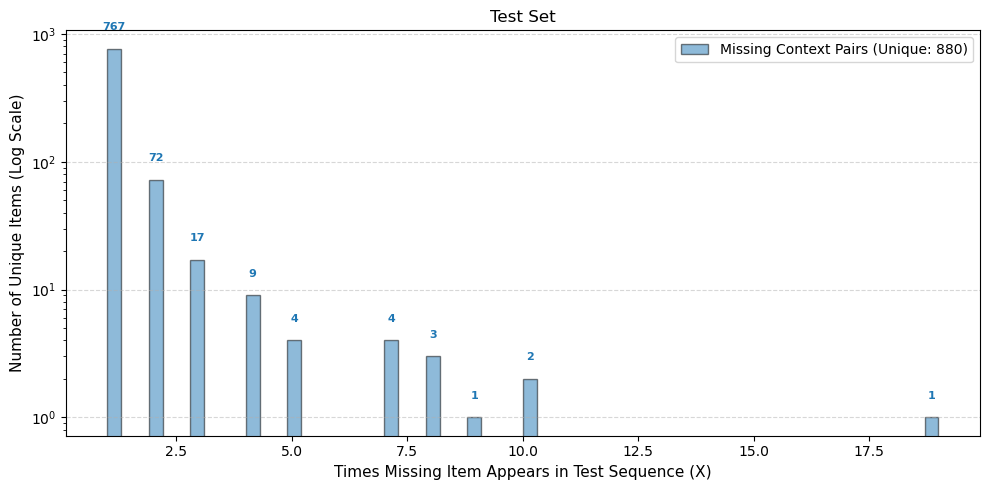

In [ ]:
plot_missing_contexts_and_tokens(
    test_ids, probs_matrix, bins=60, 
    title="Test Set"
)

In [ ]:
test_contexts = set(
    (test_ids[i - 1], test_ids[i + 1]) for i in range(1, len(test_ids) - 1)
)

wiki_contexts = set(probs_matrix.keys())

missing_in_wiki = test_contexts - wiki_contexts

missing_in_prior = test_contexts - (wiki_contexts)

total_test_ctx = len(test_contexts)

print("\n--- Contexts Missing in Prior ---")
samples_shown = 0

for i in range(1, len(test_ids) - 1):
    ctx = (test_ids[i - 1], test_ids[i + 1])

    if ctx in missing_in_prior:
        prev_str = repr(decode([ctx[0]]))
        next_str = repr(decode([ctx[1]]))
        actual_mid = repr(decode([test_ids[i]]))

        print(
            f"  {samples_shown+1}. Context: {prev_str} [ ___ ] {next_str}  "
            f"-> Actual token in test set: {actual_mid}"
        )

        samples_shown += 1
        if samples_shown >= 30:
            break

missing_triplet_counts = Counter()

for i in range(1, len(test_ids) - 1):
    prev_tok = test_ids[i - 1]
    curr_tok = test_ids[i]
    next_tok = test_ids[i + 1]

    context = (prev_tok, next_tok)
    if context in missing_in_prior:
        missing_triplet_counts[(prev_tok, curr_tok, next_tok)] += 1

total_missing_occurrences = sum(missing_triplet_counts.values())

print("\nTop Most Frequent Missing Triplets in Test Set:\n")
for idx, ((prev_tok, curr_tok, next_tok), count) in enumerate(
    missing_triplet_counts.most_common(10), 1
):
    prev_str = repr(decode([prev_tok]))
    curr_str = repr(decode([curr_tok]))
    next_str = repr(decode([next_tok]))

    print(
        f"{idx:2d}. Context: {prev_str:<12} [ {curr_str:<8} ] {next_str:<12} "
        f"-> Appeared {count} time(s)"
    )


--- Contexts Missing in Prior ---
  1. Context: 'udd' [ ___ ] 'Mar'  -> Actual token in test set: ' '
  2. Context: 'pop' [ ___ ] 'col'  -> Actual token in test set: ' '
  3. Context: 'ff' [ ___ ] 'Ab'  -> Actual token in test set: ' '
  4. Context: 'ru' [ ___ ] 'aw'  -> Actual token in test set: ' '
  5. Context: 'ie' [ ___ ] 'tion'  -> Actual token in test set: 'produc'
  6. Context: 'su' [ ___ ] 'fur'  -> Actual token in test set: 'per'
  7. Context: 'fur' [ ___ ] '.com'  -> Actual token in test set: 'ry'
  8. Context: 'diff' [ ___ ] 'st'  -> Actual token in test set: ' '
  9. Context: 'ograph' [ ___ ] '28'  -> Actual token in test set: ' '
  10. Context: 'Cam' [ ___ ] 'wh'  -> Actual token in test set: ' '
  11. Context: 'dur' [ ___ ] 'le'  -> Actual token in test set: 's'
  12. Context: 'dur' [ ___ ] 'le'  -> Actual token in test set: 's'
  13. Context: 'dur' [ ___ ] 'le'  -> Actual token in test set: 's'
  14. Context: 'dur' [ ___ ] 'le'  -> Actual token in test set: 's'
  15. C

In [ ]:
test_text = decode(train_ids[:10000])
print(test_text[:10000])

#REDIRECT Computer accessibility
}}
'''Anarchism''' is a political philosophy and movement that seeks to abolish all institutions that perpetuate authority, coercion, or hierarchy, primarily targeting the state, capitalism and organized religion. Anarchism advocates for the replacement of the state with stateless societies and voluntary free associations. Anarchism is described as being part of the libertarian wing of the socialist movement (libertarian socialism). anarchist historian Daniel Guérin described it as a synonym for libertarian socialism, and wrote that anarchism "is really a synonym for socialism. The anarchist is primarily a socialist whose aim is to abolish the exploitation of man by man. Anarchism is only one of the streams of socialist thought, that stream whose main components are concern for liberty and haste to abolish the State." In his many works on anarchism, historian Noam Chomsky describes anarchism, alongside libertarian Marxism, as the libertarian wing of soc

In [ ]:
short_train = """'''Anarchism''' is a political philosophy and movement that seeks to abolish all institutions that perpetuate authority, coercion, or hierarchy, primarily targeting the state, capitalism and organized religion. Anarchism advocates for the replacement of the state with stateless societies and voluntary free associations. Anarchism is described as being part of the libertarian wing of the socialist movement (libertarian socialism). anarchist historian Daniel Guérin described it as a synonym for libertarian socialism, and wrote that anarchism "is really a synonym for socialism. The anarchist is primarily a socialist whose aim is to abolish the exploitation of man by man. Anarchism is only one of the streams of socialist thought, that stream whose main components are concern for liberty and haste to abolish the State." In his many works on anarchism, historian Noam Chomsky describes anarchism, alongside libertarian Marxism, as the libertarian wing of socialism.|group=nb}}
Although traces of anarchist ideas are found all throughout history, modern anarchism emerged from the Enlightenment. During the latter half of the 19th and the first decades of the 20th century, the anarchist movement flourished in most parts of the world and had a significant role in workers' struggles for emancipation. Various anarchist schools of thought formed during this period. Anarchists have taken part in several revolutions, most notably in the Paris Commune, the Russian Civil War and the Spanish Civil War, whose conclusion marked the end of the classical era of anarchism. In the last decades of the 20th and into the 21st century, the anarchist movement has been resurgent, growing in popularity and influence within anti-capitalist, anti-war and anti-globalisation movements.
Anarchists employ a range of approaches to social change, often categorised as revolutionary or evolutionary, though the two frequently overlap and are reflected in a diversity of tactics. Evolutionary approaches generally favour gradual and often nonviolent change, while revolutionary approaches seek to destroy oppressive states and institutions. Many facets of human civilisation have been influenced by anarchist theory, critique, and praxis.
 – the first political philosopher to call himself an anarchist The anarchist movement appeared between Proudhon and the Saint-Imier Congress (1872), with historians arguing for both. Since the 1890s and beginning in France, ''libertarianism'' has often been used as a synonym for anarchism; its use as a synonym is still common outside the United States. Some usages of ''libertarianism'' refer to individualistic free-market philosophy only, and free-market anarchism in particular is termed ''libertarian anarchism''.
While the term ''libertarian'' has been largely synonymous with anarchism, its meaning has more recently been diluted by wider adoption from ideologically disparate groups, including both the New Left and libertarian Marxists, who do not associate themselves with authoritarian socialists or a vanguard party, and extreme cultural liberals, who are primarily concerned with civil liberties. Additionally, some anarchists use ''libertarian socialist'' to avoid anarchism's negative connotations and emphasise its connections with socialism. ''Anarchism'' is broadly used to describe the anti-authoritarian wing of the socialist movement. Anarchism is contrasted to socialist forms which are state-oriented or from above. Scholars of anarchism generally highlight anarchism's socialist credentials and criticise attempts at creating dichotomies between the two. Some scholars describe anarchism as having many influences from liberalism, and being both liberal and socialist but more so. Many scholars reject that anarcho-capitalism is anarchist, saying that it is a misunderstanding of anarchist principles. Peter Marshall states that "[i]n general anarchism is closer to socialism than liberalism. ... Anarchism finds itself largely in the socialist camp, but it also has outriders in liberalism. It cannot be reduced to socialism, and is best seen as a separate and distinctive doctrine." According to Jeremy Jennings, "[i]t is hard not to conclude that these ideas", referring to anarcho-capitalism, "are described as anarchist only on the basis of a misunderstanding of what anarchism is." Jennings adds that "anarchism does not stand for the untrammelled freedom of the individual (as the 'anarcho-capitalists' appear to believe) but, as we have already seen, for the extension of individuality and community." Nicolas Walter wrote that "anarchism does derive from liberalism and socialism both historically and ideologically. ... In a sense, anarchists always remain liberals and socialists, and whenever they reject what is good in either they betray anarchism itself. ... We are liberals but more so, and socialists but more so." Michael Newman includes anarchism as one of many socialist traditions, especially the more socialist-aligned tradition following Proudhon and Mikhail Bakunin. Brian Morris argues that it is "conceptually and historically misleading" to "create a dichotomy between socialism and anarchism."|group=nb}}
While opposition to the state is central to anarchist thought, defining ''anarchism'' is not an easy task for scholars, as there is much discussion among scholars and anarchists on the matter, and various currents perceive anarchism slightly differently. and etymology (negation of rulers).|group=nb}} Major definitional elements include the will for a non-coercive society, the rejection of the state apparatus, the belief that human nature allows humans to exist in or progress toward such a non-coercive society, and a suggestion on how to act to pursue the ideal of anarchy.
 (), whose ''Republic'' inspired Peter Kropotkin]]
The most notable precursors to anarchism in the ancient world were in China and Greece. In China, philosophical anarchism (the discussion on the legitimacy of the state) was delineated by Taoist philosophers Zhuang Zhou and Laozi. Alongside Stoicism, Taoism has been said to have had "significant anticipations" of anarchism.
Anarchic attitudes were also articulated by tragedians and philosophers in Greece. Aeschylus and Sophocles used the myth of Antigone to illustrate the conflict between laws imposed by the state and personal autonomy. Socrates questioned Athenian authorities constantly and insisted on the right of individual freedom of conscience. Cynics dismissed human law (''nomos'') and associated authorities while trying to live according to nature (''physis''). Stoics were supportive of a society based on unofficial and friendly relations among its citizens without the presence of a state.
In the Sasanian Empire (224-651 CE), Mazdak called for an egalitarian society and the abolition of monarchy, only to be soon executed by Emperor Kavad I. In Basra, religious sects preached against the state. In medieval Europe, there was no anarchistic activity except some ascetic religious movements. Various European religious sects developed anti-state and libertarian tendencies. These, and other Muslim movements, later gave birth to religious anarchism.
Renewed interest in antiquity during the Renaissance and in private judgement during the Reformation restored elements of anti-authoritarian secularism in Europe, particularly in France. Enlightenment challenges to intellectual authority (secular and religious) and the revolutions of the 1790s and 1848 all spurred the ideological development of what became the era of classical anarchism.
, one of the earliest experiments of anarchism]]
During the French Revolution, partisan groups such as the Enragés and the  saw a turning point in the fermentation of anti-state and federalist sentiments. The first anarchist currents developed throughout the 19th century: William Godwin espoused philosophical anarchism in England, morally delegitimising the state, while Max Stirner's thinking paved the way to individualism and Pierre-Joseph Proudhon's theory of mutualism found fertile soil in France. By the late 1870s, various anarchist schools of thought had become well-defined and a wave of then-unprecedented globalisation occurred from 1880 to 1914. This era of classical anarchism lasted until the end of the Spanish Civil War and is considered the golden age of anarchism.
 and allied himself with the federalists in the First International before his expulsion by the Marxists.]]
Drawing from mutualism, Mikhail Bakunin founded collectivist anarchism and entered the International Workingmen's Association, a class worker union later known as the First International that formed in 1864 to unite diverse revolutionary currents. The International became a significant political force, with Karl Marx being a leading figure and a member of its General Council. Bakunin's faction (the Jura Federation) and Proudhon's followers (the mutualists) opposed state socialism, advocating political abstentionism and small property holdings. After bitter disputes, the Bakuninists were expelled from the International by the Marxists at the 1872 Hague Congress. Anarchists were treated similarly in the Second International, being ultimately expelled in 1896. Bakunin predicted that if revolutionaries gained power by Marx's terms, they would end up the new tyrants of workers. In response to their expulsion from the First International, anarchists formed the St. Imier International. Under the influence of Peter Kropotkin, a Russian philosopher and scientist, anarcho-communism overlapped with collectivism. Anarcho-communists, who drew inspiration from the 1871 Paris Commune, advocated for free federation and for the distribution of goods according to one's needs."""
short_test = """'''Gruffudd Maredudd Bowen Rhys''' (; born 18 July 1970) is a Welsh musician, composer, producer, filmmaker and author. He performs solo and with several bands, including Super Furry Animals, which obtained mainstream success in the 1990s. He formed the electro-pop outfit Neon Neon with Boom Bip. Their album ''Stainless Style'' was nominated for the 2008 Nationwide Mercury Prize. He won the 2011 Welsh Music Prize for his album ''Hotel Shampoo'', which was followed up by ''American Interior'' in 2014, accompanied by a film, a book and a mobile app. His most recent album, ''Dim Probs'', was released in 2025. He is considered a figurehead of the era known as Cool Cymru.
Rhys was born 18 July 1970 in Haverfordwest, Wales. Bowen Rees "campaigned all his life for Welsh rights, language and culture" although he did not believe in the narrow view of nationalism, glorifying one country over another, rather that the "battle for Wales is the battle for all small nations, all small communities, all individuals in the age of genocide". Rhys's mother, Margaret Wynn Meredith, shared his father's love of writing and was a poet. After playing drums for the band Emily, Rhys found fame in Wales as the front man of Ffa Coffi Pawb. Translated, the name means 'everyone's coffee beans', though if said quickly in Welsh, it can sound like 'fuck off everyone' in English and Welsh combined.
On signing to Ankstmusik, Ffa Coffi Pawb became one of the leading bands on the Welsh music scene during the Cool Cymru movement, and released three albums – ''Clymhalio'', ''Dalec Peilon'' and ''Hei Vidal!''.
Rhys plays the guitar in an unusual style. Although he is right-handed, he learned to play left-handed on his brother's left-handed guitar. Once his brother left home, Rhys only had access to a right-handed guitar. As he had already learned to play left-handed, and rather than invert the nut and re-string it, he taught himself to play the right-handed guitar upside down so the bass strings are on the bottom. Today, Rhys still plays left-handed on an upside down right-handed guitar.
When Ffa Coffi Pawb disbanded in 1993, Rhys and drummer Dafydd Ieuan, of Rhoscefnhir, Anglesey, who had played for Catatonia, Anhrefn, Hanner Pei and many other Welsh language bands, formed the basis of Super Furry Animals. They soon settled on a line-up consisting of Rhys on vocals and guitar, Ieuan on drums, his brother Cian Ciaran (formerly of WWZZ) on keyboards, Huw Bunford (formerly of U-Thant) on guitar and Guto Pryce on bass. This line-up has remained constant to the present day, although the role of each member has become more flexible, particularly in the studio.
In 1995, following a couple of largely Welsh-language EPs on the Ankst label, they signed to Creation Records. Apparently, when offering them the deal after a gig, Alan McGee, head of Creation, asked that they sing more songs in English. Rhys pointed out that all the songs that night had been in English. Super Furry Animals went on to release their critically acclaimed first album, ''Fuzzy Logic'', in 1996 – the first time Rhys had recorded in English. He later observed that his singing sounded like a random collection of accents – but it was nevertheless very successful.
Follow-up albums included ''Radiator'' in 1997, ''Guerrilla'' in 1999 and ''Mwng'' in 2000. They also became particularly famous for their 40-foot inflatable bears and a blue tank with 'SFA' written upon it which toured summer festivals playing techno music at high volume. Super Furry Animals made a further mark on history in July 2001, when they released their first album for the Sony label, ''Rings Around the World'', on CD and DVD simultaneously. They repeated this for 2003's ''Phantom Power''. Unfortunately 2005's ''Love Kraft'' performed poorly commercially and Super Furry Animals agreed to leave Sony. They are presently signed to Rough Trade and released ''Hey Venus!'' in 2007 in the UK. In 2009 they released their latest record to date, entitled ''Dark Days/Light Years''.
, Dorset, England on 30th August 2024]]
On 24 January 2005, Rhys released his first solo album, ''Yr Atal Genhedlaeth'', on the Placid Casual label. It was a loose, sketchy, all-Welsh-language album, with most of the instruments played by Rhys. A tour of Wales and several festival appearances followed. After Super Furry Animals signed to Rough Trade, the new label agreed to take on his solo works as well, and on 8 January 2007 they released ''Candylion'', a batch of acoustic pop songs in English, Spanish and Welsh, which Rhys wrote whilst touring ''Love Kraft'' but which did not fit with the direction of the new Super Furry Animals album. A third solo album by Rhys, ''Hotel Shampoo'', was released on 14 February 2011. On 4 March 2011, it was announced that Rhys would be playing at Glastonbury 2011.
In May 2014, Rhys released his new work, ''American Interior'' (''I Grombil Cyfandir Pell''), a combined project of an album, a film, a hardback book and an app for mobile devices. The film was co-directed by Dylan Goch, who also worked with Rhys on his previous film, ''Separado!'' (2010).
From December 2015 to January 2016, Rhys fronted a co-production with National Theatre Wales titled "The Insatiable, Inflatable Candylion", featuring songs from ''Candylion'' and several new tracks. The music and lyrics were by Gruff Rhys and the play's text, which included audience participation, by Tim Price. The musicians appearing with Rhys were Lisa Jên Brown (who also sang on the original album), Sweet Baboo, Emma Daman Thomas and Kliph Scurlock. The show also included actors Remy Beasley, Matthew Bulgo, Dyfan Dwyfor, Natasha Lewis and Dyfrig Morris.
On 21 April 2016, Rhys released a new song entitled "I Love EU", a song praising the European Union ahead of the EU Referendum on 23 June 2016.
Rhys released his fifth album, entitled ''Babelsberg'', on 8 June 2018. A further album, "Pang!", was released on 13 September 2019, produced by South African DJ Muzi.
In 2007 Rhys launched a new electro-pop collaborative project with Boom Bip under the collective moniker Neon Neon. Their album, titled ''Stainless Style'', is a loose concept album based on the tumultuous life of DeLorean Motor Company founder John DeLorean, and was released on 18 March 2008 via Lex Records. The album includes a number of high-profile guest appearances from Fab Moretti of The Strokes, Har Mar Superstar, Yo Majesty, Spank Rock, Cate Le Bon and The Magic Numbers. The first single, "Raquel", was released on 26 November 2007. The follow-up single "I Lust U", featured fellow Welsh artist Cate Le Bon on vocals. The album was nominated for the 2008 Mercury Prize.
On 29 April 2013, Neon Neon released their second studio album, ''Praxis Makes Perfect'', followed by a limited run of live performances featuring actors from National Theatre Wales. The album and live show are based on the life of Giangiacomo Feltrinelli.
Rhys has occasionally collaborated with other artists, providing vocals for the track "Dial: Revenge" on the Mogwai album ''Rock Action'' as well as guesting on the songs "Fear of Guitars" (from the album ''Machine Says Yes'' by FC Kahuna) and "Do's and Don'ts" (by Boom Bip) as well as "Just War" from Danger Mouse and Sparklehorse's album ''Dark Night of the Soul''. He has also featured on the Myspace remix track "I'm Not Lying" by Goldie Lookin' Chain. He features on the track "Cream Dream" from the 2009 Simian Mobile Disco album ''Temporary Pleasure''. He also eats carrots on the Misty's Big Adventure album ''Television's People'', continuing the vegetable relay started by Brian Wilson on ''Smile''. Miles Kane has also called for him to produce the next album by his band the Rascals. Rhys also collaborated with influential hip-hop group De La Soul on the Gorillaz track "Superfast Jellyfish" from their third studio album, ''Plastic Beach.'' He later provided vocals on the song "Shadowy Light" on Gorillaz 2026 album, ''The Mountain''. In 2011 he provided vocals on the song "We Won't be Broke Forever Baby" on Akira the Don's LP ''The Life Equation.''
In 2010 he released an album with Brazilian artist Tony da Gatorra on Turnstile Music. The album featured both compositions by Tony da Gatorra, who is relatively unknown in his native Brazil, and Gruff Rhys.
On 17 December 2011, Rhys joined Manic Street Preachers on stage during the band's 38 song ''A Night of National Treasures'' one-off live event at the O2 Arena in London to provide the lead vocals for the song ''Let Robeson Sing''. Introducing Rhys to the stage, lead singer James Dean Bradfield explained that Rhys had been set to perform the song at the band's 2001 performance in Havana, Cuba but circumstances had prevented this from happening.
In 2010, Dylan Goch's film ''Separado!'' premiered. It is a documentary about Gruff Rhys's trip to Patagonia to try to locate members of his family whose ancestors had emigrated in Victorian times.
In 2014, the pair co-directed a film about the Welsh explorer John Evans, ''American Interior''. It was released in cinemas in the UK on 9 May 2014.
In 2011 Rhys composed the music for the successful iOS and Android game ''Whale Trail'' which has been an iTunes game of the week.
In 2016 Rhys composed and sang "I Love EU"  to support the Remain campaign in the UK European Membership Referendum.
In 2014, Rhys composed the film score for ''Set Fire to the Stars'' about Dylan Thomas and starring Celyn Jones"""

In [ ]:
encoded_noisy_text = generate_noise(short_train, T)
# test_corpus
encoded_clean_text = list(encode(short_train))

initial_sequence_guess = list(encoded_noisy_text)

history = []

T_intermediate = compute_intermediate_matrix(encoded_clean_text, encoded_noisy_text)

Noise:   0%|          | 0/4972 [00:00<?, ?it/s]

In [ ]:
from scipy.stats import entropy

def extract_triplets_and_contexts(sequence):
    if isinstance(sequence, torch.Tensor):
        sequence = sequence.cpu().tolist()

    triplets = []
    contexts = []
    for i in range(1, len(sequence) - 1):
        left, target, right = sequence[i - 1], sequence[i], sequence[i + 1]
        triplets.append((left, target, right))
        contexts.append((left, right))

    return triplets, contexts


def analyze_triplet_priors(
    train_seq,
    test_seq,
    short_seq,
    prior_matrix,
    vocab=None,
    max_display_triplets=15,
):
    """Compares context pair and triplet distributions across Train, Test, and Short datasets.

    Identifies exact missing context windows and unseen middle target tokens in
    'short'.
    """
    # 1. Extract Triplets and Context Pairs
    train_triplets, train_contexts = extract_triplets_and_contexts(train_seq)
    test_triplets, test_contexts = extract_triplets_and_contexts(test_seq)
    short_triplets, short_contexts = extract_triplets_and_contexts(short_seq)

    # 2. Context Pair Distributions
    train_ctx_counts = Counter(train_contexts)
    test_ctx_counts = Counter(test_contexts)
    short_ctx_counts = Counter(short_contexts)

    # 3. Analyze Coverage of 'short' and 'test' inside prior_matrix
    prior_keys = set(prior_matrix.keys())

    def analyze_dataset_coverage(dataset_name, dataset_triplets, dataset_contexts):
        unique_contexts = set(dataset_contexts)
        missing_contexts = []
        unseen_target_triplets = []
        valid_triplets = []

        for left, target, right in dataset_triplets:
            pair = (left, right)
            triplet = (left, target, right)

            if pair not in prior_keys:
                missing_contexts.append(triplet)
            else:
                # Pair exists in prior, check if target middle token was ever seen in this context
                if target not in prior_matrix[pair]:
                    unseen_target_triplets.append(triplet)
                else:
                    valid_triplets.append(triplet)

        unique_missing_ctx = set((t[0], t[2]) for t in missing_contexts)
        unique_unseen_targets = set(unseen_target_triplets)

        total_ctx = len(unique_contexts)
        matched_ctx = total_ctx - len(unique_missing_ctx)
        coverage_pct = (matched_ctx / max(1, total_ctx)) * 100.0

        return {
            "total_triplets": len(dataset_triplets),
            "unique_contexts": total_ctx,
            "matched_contexts": matched_ctx,
            "missing_contexts": missing_contexts,
            "unique_missing_ctx": unique_missing_ctx,
            "unseen_target_triplets": unseen_target_triplets,
            "unique_unseen_targets": unique_unseen_targets,
            "coverage_pct": coverage_pct,
        }

    short_coverage = analyze_dataset_coverage(
        "short", short_triplets, short_contexts
    )
    test_coverage = analyze_dataset_coverage(
        "test", test_triplets, test_contexts
    )

    # 4. Context Distribution Similarity (Cosine Similarity over shared contexts)
    all_contexts = list(
        set(train_ctx_counts.keys())
        | set(test_ctx_counts.keys())
        | set(short_ctx_counts.keys())
    )
    ctx_to_idx = {ctx: i for i, ctx in enumerate(all_contexts)}

    def build_prob_vec(counts_dict, total_len, dim):
        vec = np.zeros(dim, dtype=np.float32)
        for ctx, count in counts_dict.items():
            vec[ctx_to_idx[ctx]] = count / max(1, total_len)
        return vec

    dim = len(all_contexts)
    p_train = build_prob_vec(train_ctx_counts, len(train_contexts), dim)
    p_test = build_prob_vec(test_ctx_counts, len(test_contexts), dim)
    p_short = build_prob_vec(short_ctx_counts, len(short_contexts), dim)

    def cosine_sim(v1, v2):
        norm = np.linalg.norm(v1) * np.linalg.norm(v2)
        return float(np.dot(v1, v2) / norm) if norm > 0 else 0.0

    # 5. Print Summary Report
    print("=" * 70)
    print(" TRIPLET & CONTEXT PAIR DISTRIBUTION REPORT")
    print("=" * 70)
    print(
        f"Total Sequence Lengths -> Train: {len(train_seq):,} | Test: {len(test_seq):,} | Short: {len(short_seq):,}"
    )
    print(
        f"Total Context Triplets -> Train: {len(train_triplets):,} | Test: {len(test_triplets):,} | Short: {len(short_triplets):,}"
    )
    print("-" * 70)

    print("1. CONTEXT DISTRIBUTION SIMILARITY (Cosine Similarity):")
    print(
        f"   - Train vs Test  Context Similarity: {cosine_sim(p_train, p_test):.4f}"
    )
    print(
        f"   - Train vs Short Context Similarity: {cosine_sim(p_train, p_short):.4f}"
    )
    print("-" * 70)

    print("2. 'SHORT' TEXT PRIOR MATRIX COVERAGE:")
    print(
        f"   - Unique Context Pairs (w_left, w_right) in Short : {short_coverage['unique_contexts']:,}"
    )
    print(
        f"   - Context Pairs Found in Prior Matrix            : {short_coverage['matched_contexts']:,} ({short_coverage['coverage_pct']:.2f}%)"
    )
    print(
        f"   - Completely Missing Context Pairs               : {len(short_coverage['unique_missing_ctx']):,}"
    )
    print(
        f"   - Known Contexts with Unseen Middle Target Tokens: {len(short_coverage['unique_unseen_targets']):,}"
    )
    print("-" * 70)

    # 6. Display Specific Missing Triplets in 'short'
    print("3. MISSING CONTEXT WINDOWS IN 'SHORT' (Left Context missing from Prior):")
    if short_coverage["missing_contexts"]:
        seen_printed = set()
        count = 0
        for l, t, r in short_coverage["missing_contexts"]:
            triplet_str = f"'{decode([l])}' [ '{decode([t])}' ] '{decode([r])}'"
            if triplet_str not in seen_printed:
                seen_printed.add(triplet_str)
                print(f"   - {triplet_str}  (IDs: {l}, {t}, {r})")
                count += 1
                if count >= max_display_triplets:
                    remaining = (
                        len(short_coverage["unique_missing_ctx"]) - count
                    )
                    if remaining > 0:
                        print(f"   ... and {remaining} more missing contexts.")
                    break
    else:
        print("   None! All context pairs in 'short' exist in prior_matrix.")

    print("\n4. UNSEEN MIDDLE TARGET TRIPLETS IN 'SHORT' (Context exists, Target never seen):")
    if short_coverage["unseen_target_triplets"]:
        seen_printed = set()
        count = 0
        for l, t, r in short_coverage["unseen_target_triplets"]:
            triplet_str = f"'{decode([l])}' [ '{decode([t])}' ] '{decode([r])}'"
            if triplet_str not in seen_printed:
                seen_printed.add(triplet_str)
                print(f"   - {triplet_str}  (IDs: {l}, {t}, {r})")
                count += 1
                if count >= max_display_triplets:
                    remaining = (
                        len(short_coverage["unique_unseen_targets"]) - count
                    )
                    if remaining > 0:
                        print(
                            f"   ... and {remaining} more unseen target triplets."
                        )
                    break
    else:
        print("   None! All middle target tokens were observed in training.")

    print("=" * 70)

    return {
        "short_coverage": short_coverage,
        "test_coverage": test_coverage,
        "p_train": p_train,
        "p_short": p_short,
    }

Total Sequence Lengths -> Train: 605,937,507 | Test: 2,935,585 | Short: 4,972

Total Context Triplets -> Train: 605,937,505 | Test: 2,935,583 | Short: 4,970

1. CONTEXT DISTRIBUTION SIMILARITY (Cosine Similarity):
   - Train vs Test  Context Similarity: 0.9981
   - Train vs Short Context Similarity: 0.9563
----------------------------------------------------------------------
2. 'SHORT' TEXT PRIOR MATRIX COVERAGE:
   - Unique Context Pairs (w_left, w_right) in Short : 2,387
   - Context Pairs Found in Prior Matrix            : 2,387 (100.00%)
   - Completely Missing Context Pairs               : 0
   - Known Contexts with Unseen Middle Target Tokens: 0

In [ ]:
# results = analyze_triplet_priors(
#     train_seq=train_ids,
#     test_seq=test_ids,
#     short_seq=encoded_clean_text,
#     prior_matrix=probs_matrix,
#     vocab=vocab,
#     max_display_triplets=25,
# )

# Noisy Prior

In [ ]:
# noisy_transition_matrix = defaultdict(lambda: defaultdict(int))

# for i in tqdm(
#     range(1, len(initial_sequence_guess) - 1), desc="Building Transitions"
# ):
#     prev_tok = initial_sequence_guess[i - 1]
#     curr_tok = initial_sequence_guess[i]
#     next_tok = initial_sequence_guess[i + 1]

#     context = (prev_tok, next_tok)
#     noisy_transition_matrix[context][curr_tok] += 1

# # 2. Normalize counts to probability distributions
# noisy_probs_matrix = {}
# for context, middle_tokens in tqdm(
#     noisy_transition_matrix.items(), desc="Computing Wiki Probabilities"
# ):
#     total_occurrences = sum(middle_tokens.values())
#     noisy_probs_matrix[context] = {
#         tok: count / total_occurrences
#         for tok, count in middle_tokens.items()
#     }

# print(
#     f"\nDone! Noisy Probs Matrix created with {len(noisy_probs_matrix):,} unique contexts."
# )

In [ ]:
# lambda_shake = 0.5
# # wiki_probs_matrix

# # NOISY
# all_contexts = set(probs_matrix.keys()) | set(noisy_probs_matrix.keys())
# combinedn_probs_matrix = {}

# for ctx in tqdm(all_contexts, desc=f"Building Linear Interpolation (λ={lambda_shake})"):
#     shake_dist = probs_matrix.get(ctx)
#     noisy_dist = noisy_probs_matrix.get(ctx)

#     if shake_dist and noisy_dist:
#         all_tokens = set(shake_dist.keys()) | set(noisy_dist.keys())
#         blended = {}
#         for tok in all_tokens:
#             p_s = shake_dist.get(tok, 0.0)
#             p_w = noisy_dist.get(tok, 0.0)
#             blended[tok] = (lambda_shake * p_s) + ((1 - lambda_shake) * p_w)
            
#         combinedn_probs_matrix[ctx] = blended

#     elif shake_dist:
#         combinedn_probs_matrix[ctx] = shake_dist

#     else:
#         combinedn_probs_matrix[ctx] = noisy_dist

# print(
#     f"\ncombined_probs_matrix created successfully with {len(combinedn_probs_matrix):,} contexts!"
# )

# START SAEM LOOP

SAEM (Tensor):   0%|          | 0/10000 [00:00<?, ?it/s]


 SAEM Time Report (10000 Iterations)
to_tensor_init          | Avg:  0.0072s | Total:  72.42s ( 4.1%)
sample_text_gibbs       | Avg:  0.1674s | Total: 1674.11s (94.4%)
compute_local_stats     | Avg:  0.0002s | Total:   1.88s ( 0.1%)
update_global_stats     | Avg:  0.0000s | Total:   0.40s ( 0.0%)
update_model            | Avg:  0.0004s | Total:   4.06s ( 0.2%)
metrics_and_evaluation  | Avg:  0.0020s | Total:  19.91s ( 1.1%)
convert_to_dict         | Avg:  0.0000s | Total:   0.04s ( 0.0%)



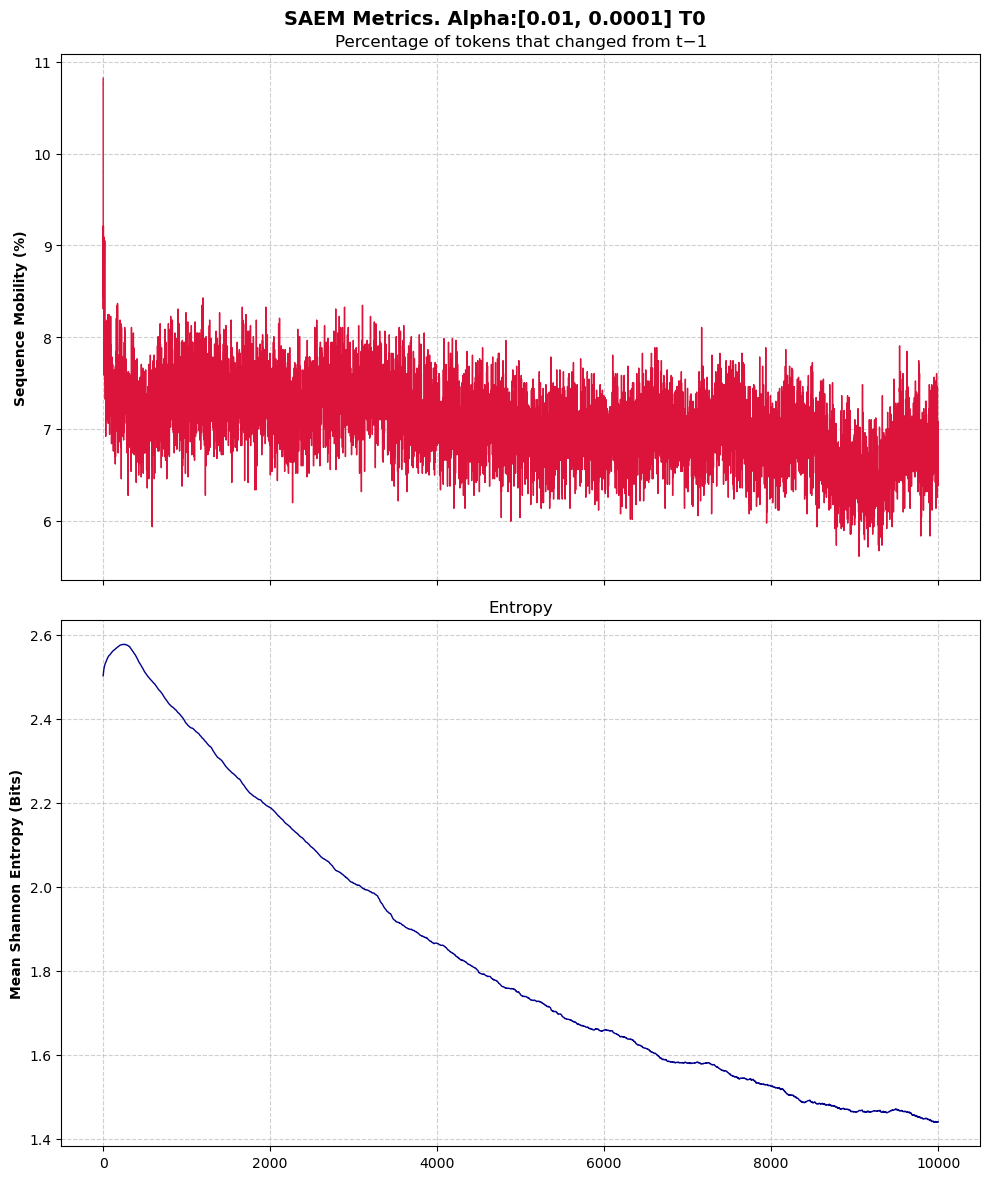

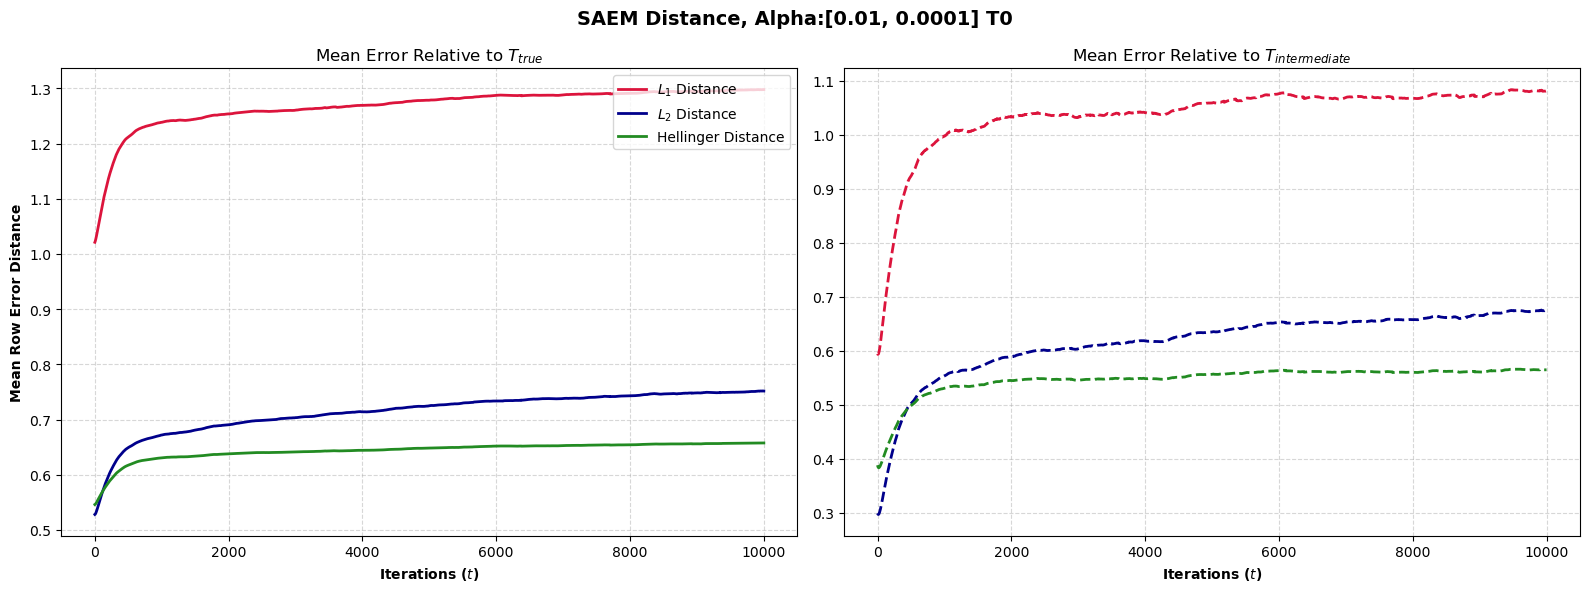

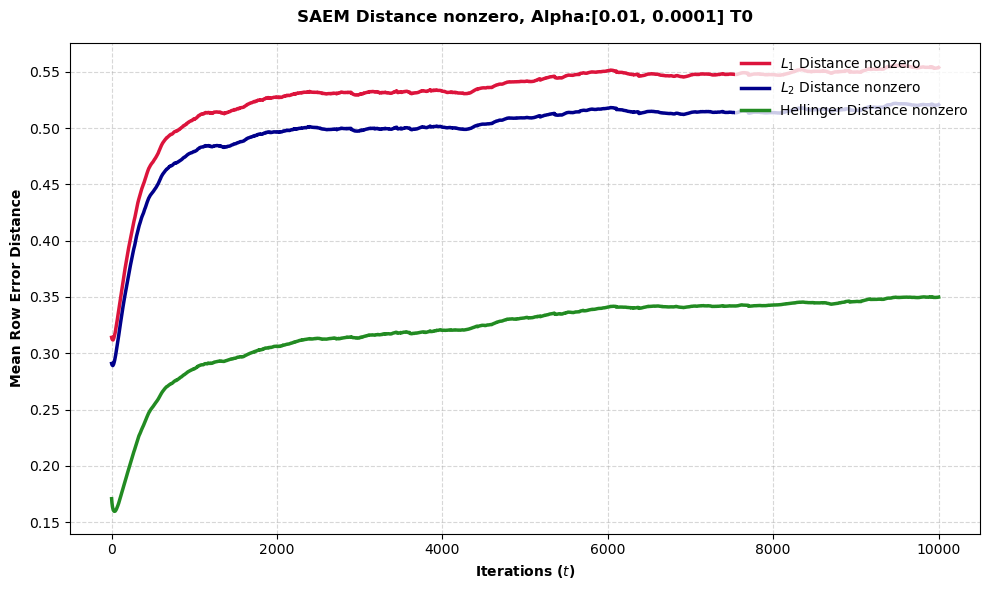

<Figure size 640x480 with 0 Axes>

SAEM (Tensor):   0%|          | 0/10000 [00:00<?, ?it/s]


 SAEM Time Report (10000 Iterations)
to_tensor_init          | Avg:  0.0064s | Total:  63.64s ( 8.4%)
sample_text_gibbs       | Avg:  0.0667s | Total: 666.96s (88.5%)
compute_local_stats     | Avg:  0.0001s | Total:   1.45s ( 0.2%)
update_global_stats     | Avg:  0.0000s | Total:   0.33s ( 0.0%)
update_model            | Avg:  0.0004s | Total:   3.59s ( 0.5%)
metrics_and_evaluation  | Avg:  0.0017s | Total:  17.31s ( 2.3%)
convert_to_dict         | Avg:  0.0000s | Total:   0.04s ( 0.0%)



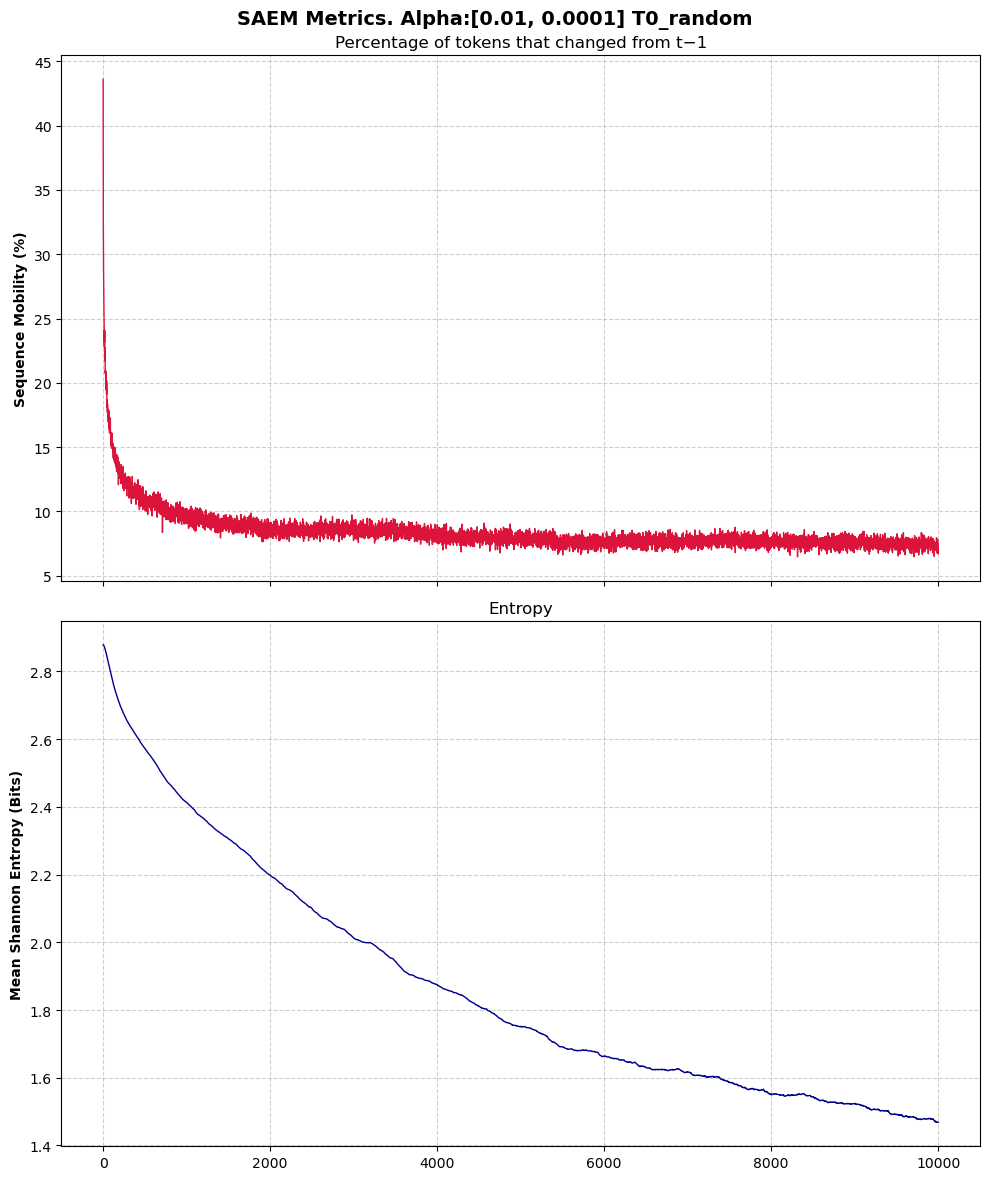

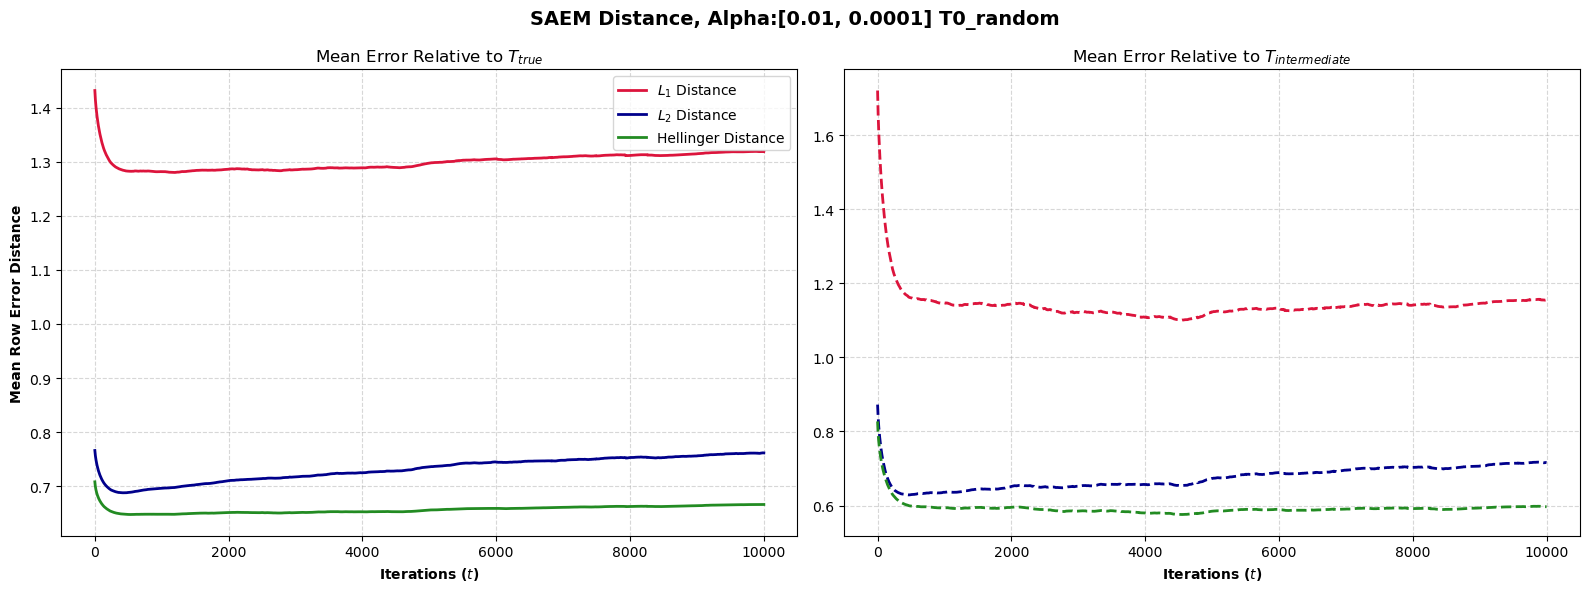

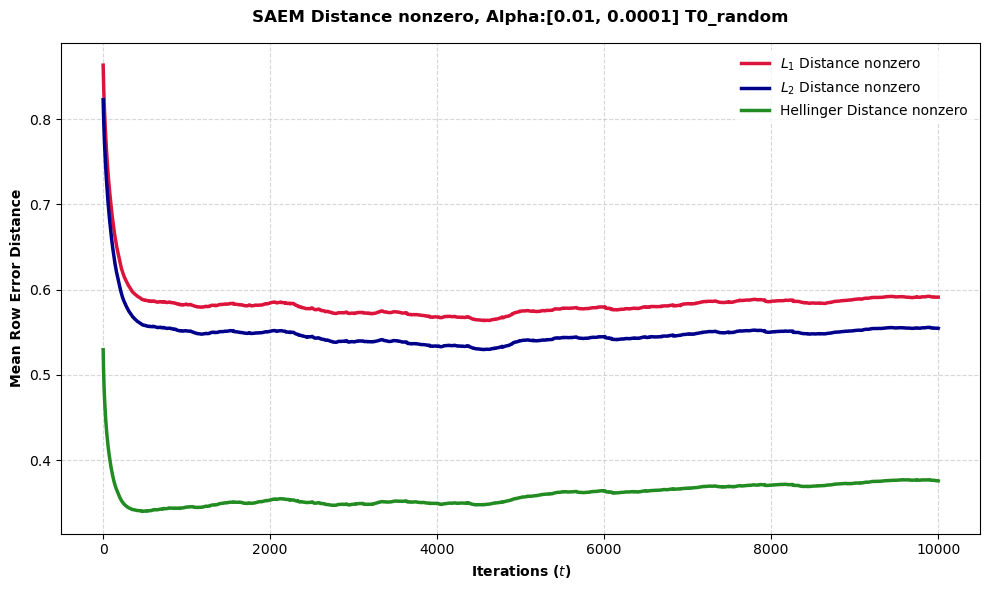

<Figure size 640x480 with 0 Axes>

In [ ]:
alpha_start = 0.01
alpha_end = 0.0001
num_iter = 10000

import gc
gc.collect()
torch.cuda.empty_cache()

estimated_T_dict_t0, history_t0 = train_saem_pure_pt(
    encoded_initial=initial_sequence_guess, 
    encoded_noisy=encoded_noisy_text, 
    prior_matrix=probs_matrix, 
    initial_T=T0,
    T_true=T, 
    T_intermediate=T_intermediate,
    T0_inv=T0_inv,
    alpha_start=alpha_start,
    alpha_end=alpha_end, 
    num_iterations=num_iter
)

plot_saem(history_t0, alpha_start, alpha_end, title="T0")
plot_saem_distance(history_t0, alpha_start, alpha_end, title="T0")

gc.collect()
torch.cuda.empty_cache()

estimated_T_dict_t0_random, history_t0_random = train_saem_pure_pt(
    encoded_initial=initial_sequence_guess, 
    encoded_noisy=encoded_noisy_text, 
    prior_matrix=probs_matrix, 
    initial_T=T0_random,
    T_true=T, 
    T_intermediate=T_intermediate,
    T0_inv=T0_inv_random,
    alpha_start=alpha_start,
    alpha_end=alpha_end, 
    num_iterations=num_iter
)

plot_saem(history_t0_random, alpha_start, alpha_end, title="T0_random")
plot_saem_distance(history_t0_random, alpha_start, alpha_end, title="T0_random")

# estimated_T_dict_t0_uniform, history_t0_uniform = train_saem_pure_pt(
#     encoded_initial=initial_sequence_guess, 
#     encoded_noisy=encoded_noisy_text, 
#     prior_matrix=probs_matrix, 
#     initial_T=T0_uniform,
#     T_true=T, 
#     T_intermediate=T_intermediate,
#     T0_inv=T0_inv_uniform,
#     alpha_start=alpha_start,
#     alpha_end=alpha_end, 
#     num_iterations=num_iter
# )

# plot_saem(history_t0_uniform, alpha_start, alpha_end, title="T0_uniform")
# plot_saem_distance(history_t0_uniform, alpha_start, alpha_end, title="T0_uniform")

In [ ]:
def plot_alpha_metric_comparison(results_dict):
    metrics = ['L1 Distance', 'L2 Distance', 'Hellinger']
    configs = list(results_dict.keys())
    num_configs = len(configs)
    
    # Layout configuration for grouped bars
    x_indexes = np.arange(len(metrics))
    total_group_width = 0.8
    bar_width = total_group_width / num_configs
    
    # Choose a cohesive color palette (using plt.get_cmap for version compatibility)
    colors = plt.get_cmap('viridis', num_configs)
    
    # Create 3-panel plot: True Matrix vs Intermediate Matrix vs Non-zero Intermediate Matrix
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    ref_keys = [
        ('true', 'True Transition Matrix (T_true)'), 
        ('int', 'Intermediate Matrix (T_intermediate)'),
        ('nonzero', 'Non-Zero Transitions only (T_intermediate)')
    ]
    
    for subplot_idx, (prefix, title_suffix) in enumerate(ref_keys):
        ax = axes[subplot_idx]
        
        # Generate bars for each alpha profile configuration
        for config_idx, config_label in enumerate(configs):
            # Compute position offset relative to base category index
            offset = (config_idx - (num_configs - 1) / 2) * bar_width
            
            # Fetch stored scalar values
            data = results_dict[config_label]
            values = [
                data[f'{prefix}_l1'], 
                data[f'{prefix}_l2'], 
                data[f'{prefix}_hellinger']
            ]
            
            # Plot individual configuration bar groups
            ax.bar(
                x_indexes + offset, 
                values, 
                width=bar_width, 
                label=config_label,
                color=colors(config_idx),
                edgecolor='black',
                linewidth=0.7,
                alpha=0.9
            )
            
        # Decorate the axes
        ax.set_title(f"Error Relative to:\n{title_suffix}", fontsize=12, pad=12, fontweight='semibold')
        ax.set_xticks(x_indexes)
        ax.set_xticklabels(metrics, fontsize=10)
        ax.set_ylabel("Distance Metric Value", fontsize=11)
        ax.grid(axis='y', linestyle=':', alpha=0.6)
        
        # Show legend only on the first plot to avoid clutter
        if subplot_idx == 0:
            ax.legend(title="Alpha Profiles", loc='upper right', framealpha=0.9)
            
    plt.tight_layout()
    plt.show()

def compare_matrices(T_true, T_intermediate, T_estimated, vocab, precision=4, limit=100):
    print("=" * 80)
    print(f"{'True Token':<15} | {'Noisy Candidate':<15} | {'True P':<12} | {'Int P':<12} | {'Est P':<12}")
    print("=" * 80)
    
    # Helper to clean and decode token IDs safely
    def get_token_str(token_id):
        if token_id in vocab:
            token_val = vocab[token_id]
            if isinstance(token_val, bytes):
                return repr(token_val.decode('utf-8', errors='replace'))
            return repr(token_val)
        return f"ID:{token_id}"

    # Base our loop iteration off the superset of tracking keys across all structures
    all_true_ids = sorted(list(set(T_intermediate.keys()) | set(T_estimated.keys())))
    cnt = 0
    
    for m_id in all_true_ids:
        if cnt > limit:
            break
        cnt += 1
        true_token_str = get_token_str(m_id)
        
        true_targets = T_true.get(m_id, {})
        int_targets = T_intermediate.get(m_id, {})
        est_targets = T_estimated.get(m_id, {})
        
        # Combine candidate spaces across all three matrices to avoid missing structural paths
        all_possible_noisy_targets = sorted(list(
            set(true_targets.keys()) | 
            set(int_targets.keys()) | 
            set(est_targets.keys())
        ))
        
        header_printed = False
        
        for k_id in all_possible_noisy_targets:
            p_true = true_targets.get(k_id, 0.0)
            p_int = int_targets.get(k_id, 0.0)
            p_est = est_targets.get(k_id, 0.0)
                
            noisy_token_str = get_token_str(k_id)
            row_label = true_token_str if not header_printed else ""
            
            print(f"{row_label:<15} | {noisy_token_str:<15} | "
                  f"{p_true:<12.{precision}f} | "
                  f"{p_int:<12.{precision}f} | "
                  f"{p_est:<12.{precision}f} | ")
            header_printed = True
            
        if header_printed:
            print("-" * 80)

def compare_matrices_nonzero(T_true, T_intermediate, T_estimated, vocab, precision=4, limit=100):
    print("=" * 80)
    print(f"{'True Token':<15} | {'Noisy Candidate':<15} | {'True P':<12} | {'Int P':<12} | {'Est P':<12}")
    print("=" * 80)
    
    # Helper to clean and decode token IDs safely
    def get_token_str(token_id):
        if token_id in vocab:
            token_val = vocab[token_id]
            if isinstance(token_val, bytes):
                return repr(token_val.decode('utf-8', errors='replace'))
            return repr(token_val)
        return f"ID:{token_id}"

    # Base our loop iteration off the superset of tracking keys across all structures
    all_true_ids = sorted(list(set(T_intermediate.keys())))
    cnt = 0
    
    for m_id in all_true_ids:
        if cnt > limit:
            break
        cnt += 1
        true_token_str = get_token_str(m_id)
        
        true_targets = T_true.get(m_id, {})
        int_targets = T_intermediate.get(m_id, {})
        est_targets = T_estimated.get(m_id, {})
        
        # Combine candidate spaces across all three matrices to avoid missing structural paths
        all_possible_noisy_targets = sorted(list(
            set(true_targets.keys()) | 
            set(int_targets.keys()) | 
            set(est_targets.keys())
        ))
        
        header_printed = False
        
        for k_id in all_possible_noisy_targets:
            p_true = true_targets.get(k_id, 0.0)
            p_int = int_targets.get(k_id, 0.0)
            p_est = est_targets.get(k_id, 0.0)
                
            noisy_token_str = get_token_str(k_id)
            row_label = true_token_str if not header_printed else ""
            
            print(f"{row_label:<15} | {noisy_token_str:<15} | "
                  f"{p_true:<12.{precision}f} | "
                  f"{p_int:<12.{precision}f} | "
                  f"{p_est:<12.{precision}f} | ")
            header_printed = True
            
        if header_printed:
            print("-" * 80)

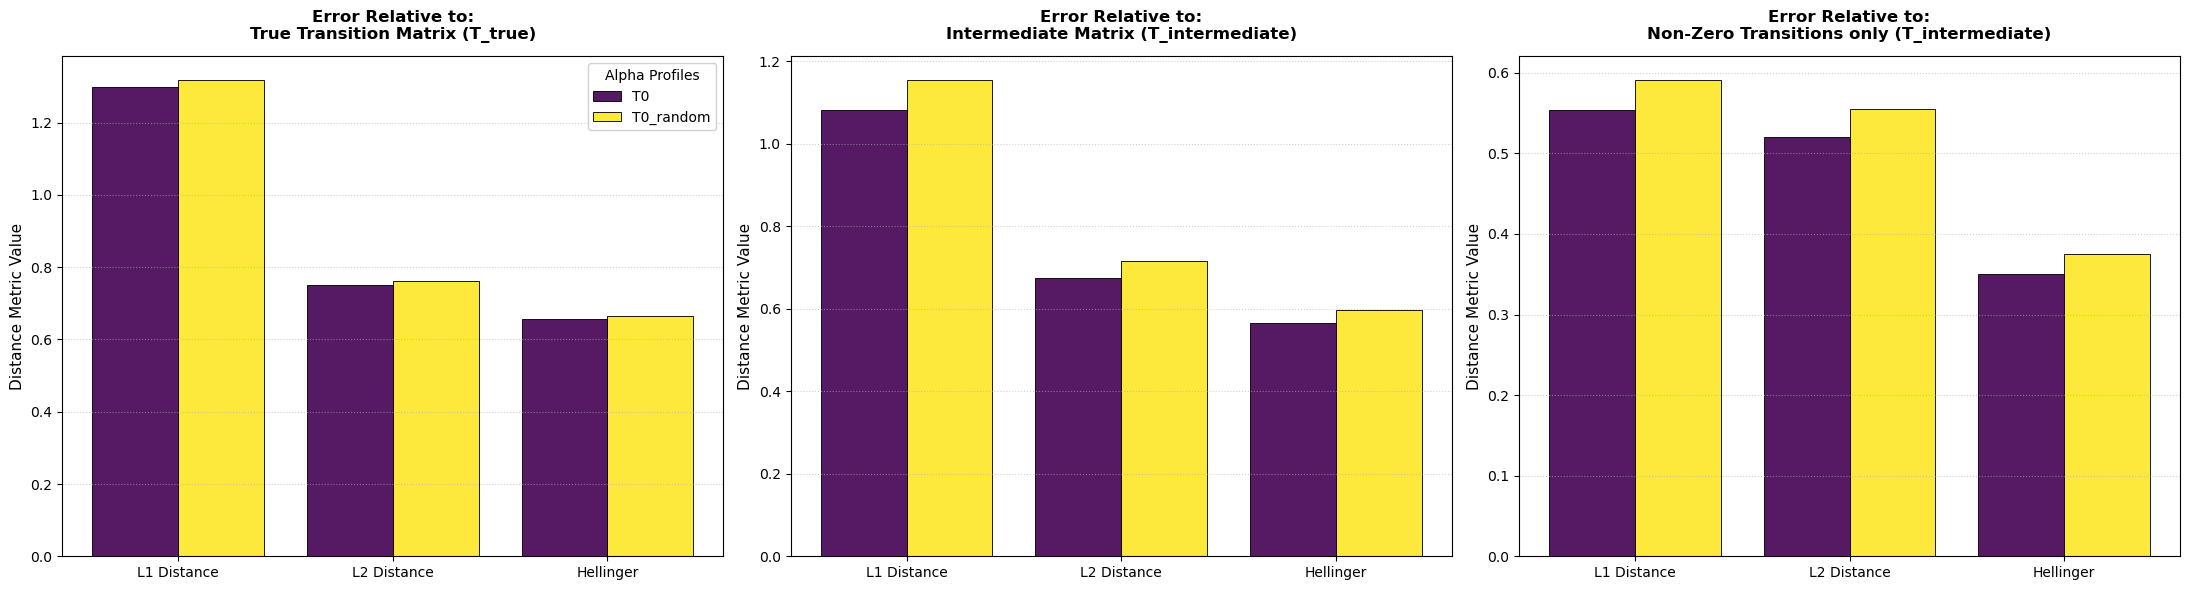

In [ ]:
sweep_results = {}

sweep_results['T0'] = {
    'true_l1': history_t0['true_l1'][-1],
    'true_l2': history_t0['true_l2'][-1],
    'true_hellinger': history_t0['true_hellinger'][-1],
    'int_l1': history_t0['int_l1'][-1],
    'int_l2': history_t0['int_l2'][-1],
    'int_hellinger': history_t0['int_hellinger'][-1],
    'nonzero_l1': history_t0['nonzero_l1'][-1],
    'nonzero_l2': history_t0['nonzero_l2'][-1],
    'nonzero_hellinger': history_t0['nonzero_hel'][-1]
}

sweep_results['T0_random'] = {
    'true_l1': history_t0_random['true_l1'][-1],
    'true_l2': history_t0_random['true_l2'][-1],
    'true_hellinger': history_t0_random['true_hellinger'][-1],
    'int_l1': history_t0_random['int_l1'][-1],
    'int_l2': history_t0_random['int_l2'][-1],
    'int_hellinger': history_t0_random['int_hellinger'][-1],
    'nonzero_l1': history_t0_random['nonzero_l1'][-1],
    'nonzero_l2': history_t0_random['nonzero_l2'][-1],
    'nonzero_hellinger': history_t0_random['nonzero_hel'][-1]
}

# sweep_results['T0_uniform'] = {
#     'true_l1': history_t0_uniform['true_l1'][-1],
#     'true_l2': history_t0_uniform['true_l2'][-1],
#     'true_hellinger': history_t0_uniform['true_hellinger'][-1],
#     'int_l1': history_t0_uniform['int_l1'][-1],
#     'int_l2': history_t0_uniform['int_l2'][-1],
#     'int_hellinger': history_t0_uniform['int_hellinger'][-1],
#     'nonzero_l1': history_t0_uniform['nonzero_l1'][-1],
#     'nonzero_l2': history_t0_uniform['nonzero_l2'][-1],
#     'nonzero_hellinger': history_t0_uniform['nonzero_hel'][-1]
# }

plot_alpha_metric_comparison(sweep_results)

In [ ]:
compare_matrices_nonzero(
    T_true=T,
    T_intermediate=T_intermediate,
    T_estimated=estimated_T_dict_t0,
    vocab=vocab,
    precision=7,
    limit=50
)
# compare_matrices(
#     T_true=T,
#     T_intermediate=T_intermediate,
#     T_estimated=estimated_T_dict_t0_random,
#     vocab=vocab,
#     precision=7,
#     limit=20
# )

True Token      | Noisy Candidate | True P       | Int P        | Est P       
'\n'            | '\n'            | 0.9000000    | 1.0000000    | 0.9992491    | 
                | '\n|'           | 0.0142238    | 0.0000000    | 0.0000000    | 
                | '\n| '          | 0.0000000    | 0.0000000    | 0.0000091    | 
                | '\n* '          | 0.0069964    | 0.0000000    | 0.0000000    | 
                | ']\n'           | 0.0140183    | 0.0000000    | 0.0000000    | 
                | '.\n*'          | 0.0069251    | 0.0000000    | 0.0000000    | 
                | '.\nA'          | 0.0000000    | 0.0000000    | 0.0000091    | 
                | '\n '           | 0.0142667    | 0.0000000    | 0.0007237    | 
                | ':\n'           | 0.0147238    | 0.0000000    | 0.0000000    | 
                | ')\n'           | 0.0147985    | 0.0000000    | 0.0000091    | 
                | '}\n'           | 0.0140473    | 0.0000000    | 0.0000000    | 
-------------------

# Decoding

In [ ]:
def belief_propagation_decode(noisy_tokens, T_matrix, prior_matrix, vocab):
    N = len(noisy_tokens)
    if N == 0:
        return [], []
    if N == 1:
        x = noisy_tokens[0]
        best_token = x
        best_prob = -1.0
        for clean_id, emissions in T_matrix.items():
            if x in emissions and emissions[x] > best_prob:
                best_prob = emissions[x]
                best_token = clean_id
        log_p = math.log(best_prob) if best_prob > 0 else -100.0
        return [best_token], [log_p]

    # 1. Invert T_matrix locally
    T_inv = defaultdict(list)
    for clean_id, observations in T_matrix.items():
        for observed_id, prob in observations.items():
            if prob > 0:
                T_inv[observed_id].append((clean_id, prob))

    def get_candidates(x_id):
        cands = [clean_id for clean_id, _ in T_inv[x_id]]
        return cands if cands else ([x_id] if x_id in vocab else [0])

    candidates_per_step = [get_candidates(x) for x in noisy_tokens]

    # 2. Initialize Viterbi table at t=0
    V = {}
    C_0 = candidates_per_step[0]
    C_1 = candidates_per_step[1]
    x_0 = noisy_tokens[0]
    x_1 = noisy_tokens[1]

    for z_0 in C_0:
        e_0 = T_matrix.get(z_0, {}).get(x_0, 0.0)
        if e_0 == 0:
            continue
        for z_1 in C_1:
            e_1 = T_matrix.get(z_1, {}).get(x_1, 0.0)
            if e_1 == 0:
                continue
            V[(z_0, z_1)] = math.log(e_0) + math.log(e_1)

    # 3. Message Passing / Forward Step
    backpointers = []

    for t in tqdm(range(1, N - 1), desc="forward"):
        C_prev = candidates_per_step[t - 1]
        C_curr = candidates_per_step[t]
        C_next = candidates_per_step[t + 1]
        x_next = noisy_tokens[t + 1]

        V_next = {}
        B_t = {}

        for z_t in C_curr:
            for z_next in C_next:
                e_next = T_matrix.get(z_next, {}).get(x_next, 0.0)
                if e_next == 0:
                    continue

                best_score = -float("inf")
                best_prev = None

                for z_prev in C_prev:
                    prev_pair_score = V.get((z_prev, z_t), -float("inf"))
                    if prev_pair_score == -float("inf"):
                        continue

                    prior_p = (
                        prior_matrix.get((z_prev, z_next), {}).get(z_t, 0.0)
                    )
                    if prior_p <= 0:
                        continue

                    score = prev_pair_score + math.log(prior_p)
                    if score > best_score:
                        best_score = score
                        best_prev = z_prev

                if best_prev is not None:
                    V_next[(z_t, z_next)] = best_score + math.log(e_next)
                    B_t[(z_t, z_next)] = best_prev

        V = V_next
        backpointers.append(B_t)

    # 4. Termination & Backtracking
    if not V or max(V.values()) == -float("inf"):
        print(
            "Warning: Decoding path broken due to zero probabilities. Falling back to noisy tokens."
        )
        return noisy_tokens, [0.0] * N

    best_pair = max(V, key=V.get)

    decoded_ids = [0] * N
    decoded_ids[N - 2] = best_pair[0]
    decoded_ids[N - 1] = best_pair[1]

    for i in tqdm(range(len(backpointers) - 1, -1, -1), desc="back"):
        t = i + 1
        z_t = decoded_ids[t]
        z_next = decoded_ids[t + 1]
        decoded_ids[t - 1] = backpointers[i][(z_t, z_next)]

    # 5. Extract Step-Level Log Probabilities Along Chosen Path
    step_log_probs = [0.0] * N
    for t in range(N):
        z_t = decoded_ids[t]
        x_t = noisy_tokens[t]

        # Emission score
        e_prob = T_matrix.get(z_t, {}).get(x_t, 1e-12)
        log_e = math.log(e_prob if e_prob > 0 else 1e-12)

        # Transition prior score for interior positions
        if 1 <= t <= N - 2:
            z_prev = decoded_ids[t - 1]
            z_next = decoded_ids[t + 1]
            prior_p = prior_matrix.get((z_prev, z_next), {}).get(z_t, 0.01)
            if prior_p == 0:
                prior_p = 0.01
            log_prior = math.log(prior_p)
            step_log_probs[t] = log_e + log_prior
        else:
            step_log_probs[t] = log_e

    return decoded_ids, step_log_probs

In [ ]:
CATEGORY_CONFIG = {
    "correct → correct": {
        "bg": "#e8f5e9",
        "text": "#2e7d32",
        "plot": "#4caf50",
    },  # Soft Green
    "wrong → correct": {
        "bg": "#e0f2f1",
        "text": "#00695c",
        "plot": "#009688",
    },  # Teal (Fixed)
    "wrong → wrong": {
        "bg": "#ffebee",
        "text": "#c62828",
        "plot": "#f44336",
    },  # Red (Unfixed)
    "correct → wrong": {
        "bg": "#fff3e0",
        "text": "#ef6c00",
        "plot": "#ff9800",
    },  # Orange (Regression)
}


def _classify_token_transitions(clean_tokens, noisy_tokens, decoded_tokens):
    """Classifies each token into one of four transition states."""
    categories = []
    for c, n, d in zip(clean_tokens, noisy_tokens, decoded_tokens):
        was_correct = n == c
        is_correct = d == c

        if was_correct and is_correct:
            categories.append("correct → correct")
        elif not was_correct and is_correct:
            categories.append("wrong → correct")
        elif not was_correct and not is_correct:
            categories.append("wrong → wrong")
        else:
            categories.append("correct → wrong")
    return categories


def visualize_token_diff(clean_tokens, noisy_tokens, decoded_tokens):
    """Renders HTML-highlighted text showing token transitions:

    - correct → correct: Green
    - wrong → correct: Teal (shows original noisy token)
    - wrong → wrong: Red (shows true clean token)
    - correct → wrong: Orange (shows true clean token)
    """
    categories = _classify_token_transitions(
        clean_tokens, noisy_tokens, decoded_tokens
    )
    html_output = [
        "<div style='font-family: monospace; line-height: 2.2; font-size: 14px; word-wrap: break-word;'>"
    ]

    for c_id, n_id, d_id, cat in zip(
        clean_tokens, noisy_tokens, decoded_tokens, categories
    ):
        c_str = decode([c_id])
        n_str = decode([n_id])
        d_str = decode([d_id])

        cfg = CATEGORY_CONFIG[cat]
        style = f"background-color: {cfg['bg']}; color: {cfg['text']}; padding: 3px 5px; margin: 1px; border-radius: 3px;"

        if cat == "correct → correct":
            html_output.append(f"<span style='{style}'>{d_str}</span>")

        elif cat == "wrong → correct":
            # Highlight successful repair
            html_output.append(
                f"<span style='{style} font-weight: bold;'>{d_str} <sub style='font-size: 10px; opacity: 0.85;'>[fixed: {n_str}]</sub></span>"
            )

        elif cat == "wrong → wrong":
            # Highlight remaining error
            html_output.append(
                f"<span style='{style} font-weight: bold;'>{d_str} <sub style='font-size: 10px; opacity: 0.85;'>[true: {c_str}]</sub></span>"
            )

        elif cat == "correct → wrong":
            # Highlight introduced regression
            html_output.append(
                f"<span style='{style} font-weight: bold;'>{d_str} <sub style='font-size: 10px; opacity: 0.85;'>[broke: {c_str}]</sub></span>"
            )

    html_output.append("</div>")
    display(HTML("".join(html_output)))


def plot_confidence_vs_errors(
    sequence_log_probs, clean_tokens, noisy_tokens, decoded_tokens
):
    """Plots Viterbi confidence score along the sequence and displays a distribution

    bar chart of the four transition states below it.
    """
    categories = _classify_token_transitions(
        clean_tokens, noisy_tokens, decoded_tokens
    )
    steps = np.arange(len(sequence_log_probs))

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 8), gridspec_kw={"height_ratios": [2.5, 1]}
    )

    # --- Top Plot: Log Probability Path with Category Scatter Overlay ---
    ax1.plot(
        steps,
        sequence_log_probs,
        color="#3f51b5",
        label="Path Log-Probability",
        alpha=0.6,
        linewidth=1.5,
    )

    # Scatter points along log-prob curve color-coded by transition state
    for cat, cfg in CATEGORY_CONFIG.items():
        indices = [i for i, c in enumerate(categories) if c == cat]
        if indices:
            ax1.scatter(
                steps[indices],
                np.array(sequence_log_probs)[indices],
                color=cfg["plot"],
                label=cat,
                s=35,
                zorder=3,
            )

    ax1.set_xlabel("Token Sequence Index (t)")
    ax1.set_ylabel("Log-Probability Score")
    ax1.set_title(
        "Decoding Confidence Path & Token Transition States",
        fontsize=12,
        fontweight="bold",
    )
    ax1.legend(loc="lower left", frameon=True)
    ax1.grid(True, linestyle="--", alpha=0.4)

    # --- Bottom Plot: Percentage Distribution Bar Chart ---
    ordered_labels = [
        "correct → wrong",
        "correct → correct",
        "wrong → wrong",
        "wrong → correct",
    ]

    total_tokens = len(categories)
    counts = pd.Series(categories).value_counts().reindex(ordered_labels, fill_value=0)
    percentages = (counts / total_tokens) * 100

    bar_colors = [CATEGORY_CONFIG[cat]["plot"] for cat in ordered_labels]

    bars = ax2.bar(ordered_labels, percentages, color=bar_colors, width=0.55)

    # Add percentage labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(
            f"{height:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=10,
        )

    ax2.set_ylabel("Percentage (%)")
    ax2.set_ylim(0, max(percentages.max() * 1.18, 10))  # Headroom for annotations
    ax2.set_title(
        "Transition Category Distribution", fontsize=11, fontweight="bold"
    )
    ax2.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

In [ ]:
decoded_token_ids_T0, log_probs_T0 = belief_propagation_decode(
    noisy_tokens=encoded_noisy_text, 
    T_matrix=estimated_T_dict_t0,
    prior_matrix=probs_matrix,
    vocab=vocab
)

decoded_token_ids_T0_random, log_probs_T0_random = belief_propagation_decode(
    noisy_tokens=encoded_noisy_text, 
    T_matrix=estimated_T_dict_t0_random,
    prior_matrix=probs_matrix,
    vocab=vocab
)

decoded_token_ids_T0_init, log_probs_T0_init = belief_propagation_decode(
    noisy_tokens=encoded_noisy_text, 
    T_matrix=T0,
    prior_matrix=probs_matrix,
    vocab=vocab
)


decoded_token_ids_T_inter, log_probs_T_inter = belief_propagation_decode(
    noisy_tokens=encoded_noisy_text, 
    T_matrix=T_intermediate,
    prior_matrix=probs_matrix, 
    vocab=vocab
)

forward:   0%|          | 0/4970 [00:00<?, ?it/s]

back:   0%|          | 0/4970 [00:00<?, ?it/s]

forward:   0%|          | 0/4970 [00:00<?, ?it/s]

KeyboardInterrupt: 

Decoding Method                     | Accuracy  
------------------------------------------------------------
1. Raw Noisy                        | 90.47%
2. Good T0                          | 98.11%
=====
T0


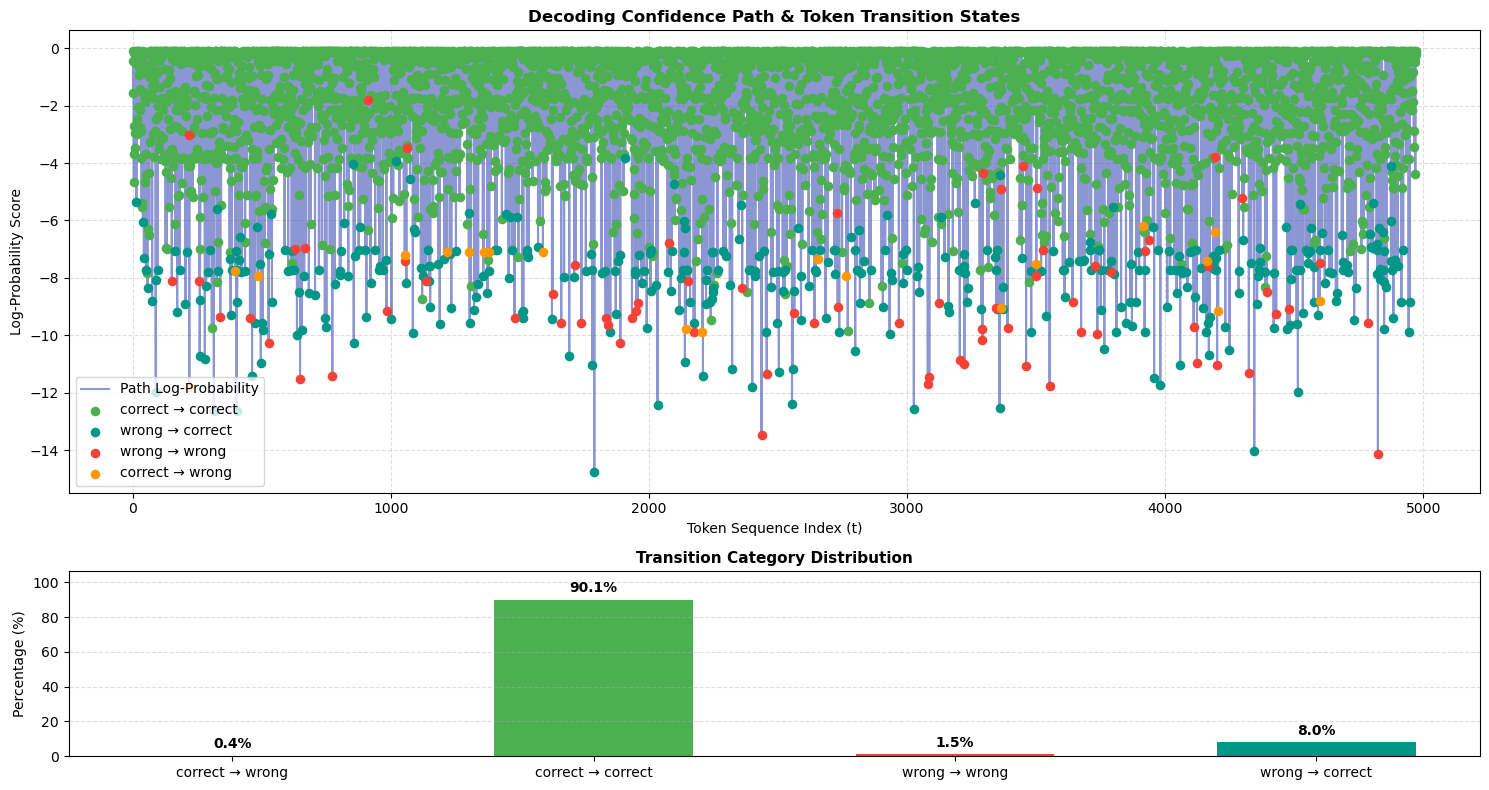

=====


In [ ]:
def calculate_accuracy(pred, target):
    return sum(1 for p, t in zip(pred, target) if p == t) / len(target) * 100

acc_noisy = calculate_accuracy(encoded_noisy_text, encoded_clean_text) #noisy text

# acc_true = calculate_accuracy(decoded_token_ids, encoded_clean_text) #using T_true
acc_t0  = calculate_accuracy(decoded_token_ids_T0, encoded_clean_text) #using T_0 good guess
acc_t0_random = calculate_accuracy(decoded_token_ids_T0_random, encoded_clean_text) #using T_0 random initial
acc_t0_init = calculate_accuracy(decoded_token_ids_T0_init, encoded_clean_text) #using T_0 initial
# acc_t0_uniform = calculate_accuracy(decoded_token_ids_T0_uniform, encoded_clean_text) #using T_0 uniform initial
acc_t_inter = calculate_accuracy(decoded_token_ids_T_inter, encoded_clean_text)

print("=" * 60)
print(f"{'Decoding Method':<35} | {'Accuracy':<10}")
print("-" * 60)
print(f"{'1. Raw Noisy':<35} | {acc_noisy:.2f}%")
# print(f"{'2. True T':<35} | {acc_true:.2f}%")
print(f"{'2. Good T0':<35} | {acc_t0:.2f}%")
print(f"{'3. T0 Random':<35} | {acc_t0_random:.2f}%")
print(f"{'4. T0 First Guess':<35} | {acc_t0_init:.2f}%")
# print(f"{'5. T0 uniform':<35} | {acc_t0_uniform:.2f}%")
print(f"{'6. T Intermediate':<35} | {acc_t_inter:.2f}%")
print("=" * 60)

# print("T")
# visualize_token_diff(
#     clean_tokens=encoded_clean_text, 
#     decoded_tokens=decoded_token_ids
# )
print("=====")
print("T0")

visualize_token_diff(
    clean_tokens=encoded_clean_text,
    noisy_tokens=initial_sequence_guess,
    decoded_tokens=decoded_token_ids_T0_init
)

plot_confidence_vs_errors(
    sequence_log_probs = log_probs_T0_init,
    clean_tokens=encoded_clean_text,
    noisy_tokens=initial_sequence_guess,
    decoded_tokens=decoded_token_ids_T0_init,
)

print("=====")

print("T0 Random")
visualize_token_diff(
    clean_tokens=encoded_clean_text, 
    noisy_tokens=initial_sequence_guess,
    decoded_tokens=decoded_token_ids_T0_random
)

plot_confidence_vs_errors(
    sequence_log_probs= log_probs_T0_random,
    clean_tokens=encoded_clean_text,
    noisy_tokens=initial_sequence_guess,
    decoded_tokens=decoded_token_ids_T0_random,
)
print("=====")
print("T0 Initial")
visualize_token_diff(
    clean_tokens=encoded_clean_text, 
    noisy_tokens=initial_sequence_guess,
    decoded_tokens=decoded_token_ids_T0_init
)

plot_confidence_vs_errors(
    sequence_log_probs= log_probs_T0_init,
    clean_tokens=encoded_clean_text,
    noisy_tokens=initial_sequence_guess,
    decoded_tokens=decoded_token_ids_T0_init,
)

print("=====")
print("T Intermediate")
visualize_token_diff(
    clean_tokens=encoded_clean_text, 
    decoded_tokens=decoded_token_ids_T_inter
)

find small part in test which doesnt contain any missing tokens and test